In [1]:
import sys

In [2]:
print(sys.path)
print(sys.executable)

['/opt/homebrew/anaconda3/envs/optimization_env_munc/lib/python310.zip', '/opt/homebrew/anaconda3/envs/optimization_env_munc/lib/python3.10', '/opt/homebrew/anaconda3/envs/optimization_env_munc/lib/python3.10/lib-dynload', '', '/opt/homebrew/anaconda3/envs/optimization_env_munc/lib/python3.10/site-packages']
/opt/homebrew/anaconda3/envs/optimization_env_munc/bin/python


In [3]:
try:
    import sklearn
    print('scikit-learn installed, version:', sklearn.__version__)
except Exception as e:
    print('scikit-learn not importable:', e)

scikit-learn installed, version: 1.7.2


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
import pandas as pd
from munc13 import Munc13, Solver

In [5]:
import sys
print(sys.path)

['/opt/homebrew/anaconda3/envs/optimization_env_munc/lib/python310.zip', '/opt/homebrew/anaconda3/envs/optimization_env_munc/lib/python3.10', '/opt/homebrew/anaconda3/envs/optimization_env_munc/lib/python3.10/lib-dynload', '', '/opt/homebrew/anaconda3/envs/optimization_env_munc/lib/python3.10/site-packages']


In [6]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [7]:
parameter_ranges = {
        "kfsr":      {"min": 0.001, "max": 10},   # kfSR uM-1s-1
        #"krsr_nostim":      {"min": 0.1,   "max": 1000}, # krSR_nostim
        "krsr":       {"min": 0.001,   "max": 1000}, # krSR_stim s-1
        "kfmm":      {"min": 0.1, "max": 10},   # kfMM uM-1s-1
        "krmm":      {"min": 0.01,   "max": 10}, # krMM s-1
        "kfmx":      {"min": 0.001, "max": 10},   # kf1x uM-1s-1
        "krmx":      {"min": 0.01,   "max": 1000}, # kr1x s-1
       # "kfc_nostim":      {"min": 0.001, "max": 10},   # kfc_nostim
        "kfc":      {"min": 0.001, "max": 10},   # kfc_stim uM-1s-1
        "krc":      {"min": 0.01, "max": 1000},   # krc
        "kfq":      {"min": 0.001, "max": 10},   # kx2 uM-1s-1
        "krq":      {"min": 0.01,   "max": 1000}, # krx2 s-1
        "eLoop":      {"min": 0.0001,   "max": 10}, # exp(free energy kT units <0).
        "eDF":      {"min": 0.0001,   "max": 10}, # exp(free energy kT units <0).
        "kfdd":     {"min": 0.01,   "max": 1}, # kfdd unimolecular: s-1
        "Sd":     {"min": 0.1,   "max": 10}, # scalar to change on/off kinetics of dimer to cluster
        "stimUpSR":       {"min": 1,   "max": 100}, # stimUpSR: scale factor >1
        "S0":        {"min": 0.001, "max": 5},   # S0 (uM)
        "R0":        {"min": 0.1, "max": 10000},   # R0 (/um^2)
        #"D1":        {"min": 0.05,   "max": 5}, # D1
        #"D1_over_D2":        {"min": 1.5,   "max": 5}, # D2
        "X0":        {"min": 0.01,   "max": 100}, # X0  (/um^2)
        "Q0":       {"min": 0.01,   "max":  100}, # Q0  (/um^2)
       
         
}



    # Order in which the solver will read parameters from a candidate
    # so, e.g. candidate[0] = kfsr.
   
params_to_optimize1 = np.array([
        "kfsr","krsr","kfmm","krmm","kfmx","krmx","kfc","krc","kfq","krq","eLoop","eDF","kfdd","Sd","stimUpSR","S0","R0","X0","Q0"
])
# Instantiate the model and solver
maxTime=1000.0
model = Munc13(parameter_ranges, params_to_optimize1, t_max=maxTime)

Gamma is 333.3333333333333


# List the numbers of all Results files and the text name of the file

In [8]:
#---These files include Q as a parameter. D as a fitness term---#
#fileNums=[251, 999, 7882, 1905, 2331, 898, 9288, 2104, 8778, 5975, 1015]
#fileResults="testParms_Dterm_Lifetimes"

#---These files set Q=0. D is a fitness term--#
#fileNums=[29, 3513, 463, 4323, 1808]
#fileResults = "testParms_noQ_Lifetimes"
#fileName = f"../data/{fileResults}_{fileNums[0]}.txt"
#----these files set Q=0. D and lifetime are fitness terms --#
#fileNums=[8537, 5049, 632, 4554, 3447, 4106, 558, 7678, 374, 7112, 6620]
#-----these files are same as above, but pop size = 50K or 30K with 6 gens---#
#fileNums = [9353, 6122, 4167, 5645, 6614, 8967, 8212, 8906, 4627, 2051, 2252, 1295, 1679, 1277, 9730, 8958, 6201]
#fileResults = "testParms_noQ_ChiLifetimes"
#fileName = f"../data/{fileResults}_{fileNums[0]}.txt"
#-----thes files are same as above, but we switche d to tournament style, and indpb=0.75---#
fileNums = [9526, 2103, 9389, 4167, 7500]
fileResults = "testParms_tourn_ChiLifetimes"
fileName = f"../data/{fileResults}_{fileNums[0]}.txt"

print("First file to open...: ", fileName)
unique_id=8888
print("unique id to label files: ", unique_id)

First file to open...:  ../data/testParms_tourn_ChiLifetimes_9526.txt
unique id to label files:  8888


START HERE TO PERFORM CLUSTERING

In [9]:
#read in all solutions in the output file.
import pandas as pd


fileName = f"../data/{fileResults}_{fileNums[0]}.txt"

dataF = pd.read_csv(fileName, sep=",", engine="python")
dataF.columns = dataF.columns.str.strip()
#dataF = dataF.sort_values(by="Rank")
print(dataF.shape)
#print(dataF.loc[25])
#store the parameters in the param_cols vector
param_cols = [col for col in dataF.columns if col not in ["Rank", "Fitness"]]
print(param_cols)

log_param_cols = [col for col in dataF.columns if col not in ["Rank", "Fitness","Sd","stimUpSR"]]
print(log_param_cols)



(107858, 21)
['kfsr', 'krsr', 'kfmm', 'krmm', 'kfmx', 'krmx', 'kfc', 'krc', 'kfq', 'krq', 'eLoop', 'eDF', 'kfdd', 'Sd', 'stimUpSR', 'S0', 'R0', 'X0', 'Q0']
['kfsr', 'krsr', 'kfmm', 'krmm', 'kfmx', 'krmx', 'kfc', 'krc', 'kfq', 'krq', 'eLoop', 'eDF', 'kfdd', 'S0', 'R0', 'X0', 'Q0']


(-110.0, 10.0)

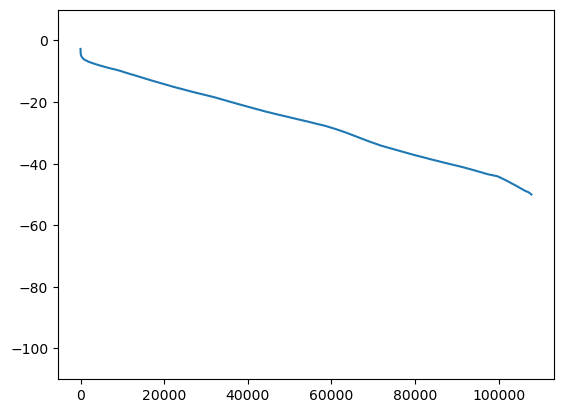

In [10]:
#plot the index vs the fitness for this dataset
plt.plot(dataF['Rank'], dataF['Fitness'])
plt.ylim([-110, 10])

In [11]:
#Only keep values of the dataset that have a fitness better than a threshold
fitness_threshold = -20
# Filter the DataFrame to only include rows with Fitness greater than the threshold
filtered_dataF = dataF[dataF['Fitness'] > fitness_threshold]
print(f"Number of rows with Fitness > {fitness_threshold}: {filtered_dataF.shape[0]}")
print(filtered_dataF.head())
#print(filtered_dataF.tail())

Number of rows with Fitness > -20: 36046
   Rank  Fitness      kfsr       krsr     kfmm      krmm      kfmx       krmx  \
0     0  -2.7297  3.796800  27.101000  0.91023  0.041931  0.872320  18.677000   
1     1  -2.8669  0.017974   0.041132  9.34170  1.713900  1.359100   0.661680   
2     2  -3.2305  0.003861   0.016640  9.34170  0.612520  0.005483   0.041578   
3     3  -3.3099  0.003861   0.009387  9.34170  1.713900  0.338370  22.861000   
4     4  -3.4853  0.003861   0.016640  0.73188  0.074923  0.043237   0.058613   

      kfc       krc  ...        krq    eLoop       eDF      kfdd       Sd  \
0  7.7286  0.024674  ...    0.62915  3.40270  0.006162  0.089751  0.96770   
1  4.1214  0.325500  ...  120.94000  0.32094  0.006162  0.102810  1.31540   
2  8.3342  0.014311  ...    0.56766  7.97710  0.000503  0.036612  0.96770   
3  8.9009  0.049359  ...  131.44000  2.93210  0.006162  0.145440  0.61177   
4  4.4804  0.106370  ...    3.17200  1.08570  0.006162  0.089751  0.96770   

   stimUp

In [12]:
#store the very best solution from each GA run.
selected_solutions = filtered_dataF.nlargest(1, 'Fitness').copy()
print(selected_solutions)

   Rank  Fitness    kfsr    krsr     kfmm      krmm     kfmx    krmx     kfc  \
0     0  -2.7297  3.7968  27.101  0.91023  0.041931  0.87232  18.677  7.7286   

        krc  ...      krq   eLoop       eDF      kfdd      Sd  stimUpSR  \
0  0.024674  ...  0.62915  3.4027  0.006162  0.089751  0.9677    2.6779   

         S0      R0      X0            Q0  
0  0.004432  453.57  0.0235  5.095300e-50  

[1 rows x 21 columns]


In [13]:
#read in multiple datasets, filter for fitness threshold and concatenate before clustering.

for num in range(1,len(fileNums)):
    fileName = f"../data/{fileResults}_{fileNums[num]}.txt"
    print("Read filename: ", fileName)
    dataF = pd.read_csv(fileName, sep=",", engine="python")
    dataF.columns = dataF.columns.str.strip()
    threshold_dataF = dataF[dataF['Fitness'] > fitness_threshold]
    print(f"Number of rows with Fitness > {fitness_threshold}: {filtered_dataF.shape[0]}")
    tempDF = pd.concat([filtered_dataF, threshold_dataF])
    filtered_dataF=tempDF
    top1 = threshold_dataF.nlargest(1, 'Fitness').copy()
    tempTop = pd.concat([selected_solutions, top1])
    selected_solutions=tempTop
print("size of new dataset: ", filtered_dataF.shape)


Read filename:  ../data/testParms_tourn_ChiLifetimes_2103.txt
Number of rows with Fitness > -20: 36046
Read filename:  ../data/testParms_tourn_ChiLifetimes_9389.txt
Number of rows with Fitness > -20: 71721
Read filename:  ../data/testParms_tourn_ChiLifetimes_4167.txt
Number of rows with Fitness > -20: 106044
Read filename:  ../data/testParms_tourn_ChiLifetimes_7500.txt
Number of rows with Fitness > -20: 145942
size of new dataset:  (181000, 21)


In [14]:
print(filtered_dataF[0:10])

   Rank  Fitness      kfsr       krsr     kfmm      krmm      kfmx       krmx  \
0     0  -2.7297  3.796800  27.101000  0.91023  0.041931  0.872320  18.677000   
1     1  -2.8669  0.017974   0.041132  9.34170  1.713900  1.359100   0.661680   
2     2  -3.2305  0.003861   0.016640  9.34170  0.612520  0.005483   0.041578   
3     3  -3.3099  0.003861   0.009387  9.34170  1.713900  0.338370  22.861000   
4     4  -3.4853  0.003861   0.016640  0.73188  0.074923  0.043237   0.058613   
5     5  -3.5446  0.051197   0.016640  0.73188  0.041931  0.872320  18.677000   
6     6  -3.5475  0.428220   0.774460  1.00640  0.071005  2.887400   0.016939   
7     7  -3.6384  0.010476   0.059678  0.80110  0.027457  0.007101   0.034642   
8     8  -3.6432  0.013465   0.001279  0.91024  0.099663  0.063449   0.039696   
9     9  -3.6648  0.001915   0.008566  8.30150  0.870960  0.137790   0.058613   

      kfc       krc  ...         krq    eLoop       eDF      kfdd       Sd  \
0  7.7286  0.024674  ...    0.

In [15]:
print("top solutions: ", selected_solutions)

top solutions:     Rank  Fitness      kfsr       krsr     kfmm      krmm      kfmx      krmx  \
0     0  -2.7297  3.796800  27.101000  0.91023  0.041931  0.872320  18.67700   
0     0  -2.6158  0.023554   0.127900  0.90090  0.135980  0.129710   1.28230   
0     0  -2.8764  0.001546   0.003705  0.10000  0.017522  0.183910   0.55775   
0     0  -2.7394  0.143610   0.002388  0.65861  0.086047  0.893600   0.33299   
0     0  -3.1336  0.048675   0.520720  2.05080  0.117900  0.040422   1.84290   

      kfc       krc  ...       krq    eLoop       eDF      kfdd       Sd  \
0  7.7286  0.024674  ...  0.629150  3.40270  0.006162  0.089751  0.96770   
0  2.5183  0.064646  ...  0.076749  1.29460  0.010672  0.085112  1.01940   
0  3.5913  0.215140  ...  0.765990  0.43092  0.003210  0.984540  0.97411   
0  4.6144  0.445420  ...  1.196000  0.18477  0.015819  0.055815  0.99576   
0  6.6459  0.012677  ...  1.493400  5.56340  0.000125  0.427570  2.01760   

   stimUpSR        S0         R0        X0    

(-25.0, -1.0)

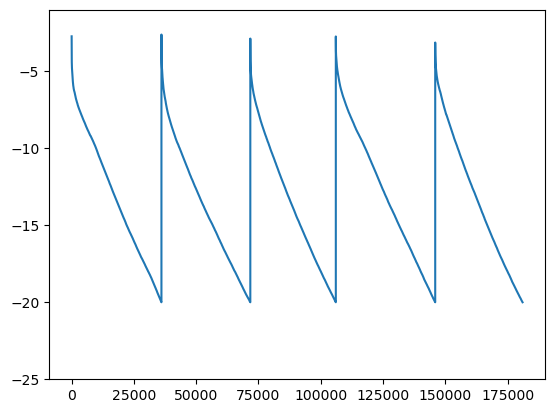

In [16]:
xVals = np.arange(0, filtered_dataF.shape[0])
plt.plot(xVals, filtered_dataF['Fitness'])
plt.ylim([-25, -1])

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import math

In [18]:


#cols = ['kfmm','krmm','kfc']   # example feature columns
X = filtered_dataF[param_cols].values
print(param_cols)
print(X.shape)
print(X[1,:])
logX = np.log10(X)
print(logX[1,:])
print(10 ** logX[1,:])

['kfsr', 'krsr', 'kfmm', 'krmm', 'kfmx', 'krmx', 'kfc', 'krc', 'kfq', 'krq', 'eLoop', 'eDF', 'kfdd', 'Sd', 'stimUpSR', 'S0', 'R0', 'X0', 'Q0']
(181000, 19)
[1.7974e-02 4.1132e-02 9.3417e+00 1.7139e+00 1.3591e+00 6.6168e-01
 4.1214e+00 3.2550e-01 1.5314e-02 1.2094e+02 3.2094e-01 6.1623e-03
 1.0281e-01 1.3154e+00 2.7402e+00 6.2255e-03 2.3628e+02 2.4008e-02
 5.5169e-50]
[ -1.74535526  -1.38582017   0.97042592   0.23398548   0.13325141
  -0.17935199   0.61504477  -0.48744901  -1.81491136   2.08256996
  -0.49357615  -2.21025716  -0.98796464   0.11905784   0.43778226
  -2.20582576   2.37342696  -1.61964402 -49.25830489]
[1.7974e-02 4.1132e-02 9.3417e+00 1.7139e+00 1.3591e+00 6.6168e-01
 4.1214e+00 3.2550e-01 1.5314e-02 1.2094e+02 3.2094e-01 6.1623e-03
 1.0281e-01 1.3154e+00 2.7402e+00 6.2255e-03 2.3628e+02 2.4008e-02
 5.5169e-50]


In [19]:
#perform clustering on the parameter sets
#first transform all data.
#Standard Scaler will evaluate the mean and variance, taking all values, subtracting means and dividing by variants.
#for all rates, they should be in log-transformed values.
scaler=StandardScaler()
Xs = scaler.fit_transform(logX)

In [20]:
nCluster = 30
kmeans = KMeans(n_clusters=nCluster, init='k-means++')

In [21]:
labels = kmeans.fit_predict(Xs)

In [22]:
centroids_scaled = kmeans.cluster_centers_             # in scaled space
centroids_original = scaler.inverse_transform(centroids_scaled)
#return the original values back to their non-log-transformed values.
centroid_10 = 10 ** centroids_original
print(centroids_original.shape)
print("first center, log10 ",centroids_original[1,:])
print("0 center, lin units ", centroid_10[0,:])
filtered_dataF['cluster'] = labels         # attach labels back to DataFrame
print("number of rows ", labels.shape)
print("labels for first 10 rows ", labels[1:10])
print(filtered_dataF[0:10])

(30, 19)
first center, log10  [  0.21828481  -0.49336401  -0.08739725  -1.3570896   -0.4508063
  -0.75121961   0.50300837  -1.10678106  -1.85293348   1.48055145
   0.33084751  -2.3436498   -0.96756309   0.10749883   0.71414556
  -2.34265167   1.70087122  -1.71234624 -49.70239438]
0 center, lin units  [3.29321539e-02 2.35809267e-02 2.65528673e+00 2.85646928e-01
 4.46304286e-01 1.02561100e+00 3.56645131e+00 3.33787262e-02
 2.32586588e-02 4.59040383e-01 4.21211174e+00 6.01086609e-04
 3.41144344e-01 2.23303321e+00 4.58127009e+00 9.72771971e-03
 1.35010966e+02 1.95081436e-02 2.96678685e-50]
number of rows  (181000,)
labels for first 10 rows  [ 5  0  5 12  9  4 18 21  5]
   Rank  Fitness      kfsr       krsr     kfmm      krmm      kfmx       krmx  \
0     0  -2.7297  3.796800  27.101000  0.91023  0.041931  0.872320  18.677000   
1     1  -2.8669  0.017974   0.041132  9.34170  1.713900  1.359100   0.661680   
2     2  -3.2305  0.003861   0.016640  9.34170  0.612520  0.005483   0.041578   
3 

In [23]:
# Find the size of each cluster (number of elements per cluster)
cluster_counts = filtered_dataF['cluster'].value_counts().sort_index()
#print("Cluster sizes:")
#print(cluster_counts)

# Example: count how many elements have a particular value, e.g., cluster label 16
label_to_check = 3
count_label = (filtered_dataF['cluster'] == label_to_check).sum()
print(f"Number of elements with cluster label {label_to_check}: {count_label}")

# Calculate the mean fitness of all elements in each cluster
mean_fitness_per_cluster = filtered_dataF.groupby('cluster')['Fitness'].mean().sort_index()
#print("Mean fitness per cluster:")
#print(mean_fitness_per_cluster)
print(mean_fitness_per_cluster[label_to_check])
#print(filtered_dataF.loc[1658])
#print(filtered_dataF.loc[1659])
sorted_fitness = mean_fitness_per_cluster.sort_values(ascending=False)
sorted_clusters = sorted_fitness.index.tolist()
print("Sorted mean fitness per cluster:")
print(sorted_fitness)
print("Order of clusters by mean fitness:", sorted_clusters)
sorted_size=cluster_counts.sort_values(ascending = False)
sorted_cluster_sizes = sorted_size.index.tolist()
print("Sorted cluster sizes")
print(sorted_size)
print("order of clusters by size:",sorted_cluster_sizes)

#find the indexes of all the elements in a specific cluster
indexes_in_cluster = filtered_dataF.index[filtered_dataF['cluster'] == label_to_check].tolist()
print(f"Indexes of elements in cluster {label_to_check}: (first 10)", indexes_in_cluster[0:10])


Number of elements with cluster label 3: 5608
-11.621244846647645
Sorted mean fitness per cluster:
cluster
10   -10.926668
22   -11.531654
3    -11.621245
18   -11.622214
27   -11.796490
20   -11.898693
26   -12.610809
11   -12.672179
29   -12.679726
12   -12.712065
1    -12.764190
5    -12.964233
19   -12.991230
0    -13.016657
9    -13.070675
7    -13.071842
23   -13.164933
4    -13.318294
16   -13.347957
17   -13.422245
2    -13.896715
14   -13.976443
13   -14.148209
21   -14.739673
6    -14.797720
15   -15.553815
24   -16.691016
28   -17.277311
8    -17.365683
25   -17.592849
Name: Fitness, dtype: float64
Order of clusters by mean fitness: [10, 22, 3, 18, 27, 20, 26, 11, 29, 12, 1, 5, 19, 0, 9, 7, 23, 4, 16, 17, 2, 14, 13, 21, 6, 15, 24, 28, 8, 25]
Sorted cluster sizes
cluster
27    8389
10    8325
14    7648
11    7499
5     7188
20    7136
22    7031
12    6841
13    6827
26    6766
23    6677
7     6673
19    6334
0     6290
18    6084
29    5751
4     5700
8     5638
3     5608

In [24]:
centroid_df = pd.DataFrame(centroid_10, columns=param_cols)
#assign the fitness based on the mean fitness.

centroid_df['Fitness']=mean_fitness_per_cluster
#now resort the clusters by fitness values
cols = centroid_df.columns.tolist()
cols = ['Fitness'] + [col for col in cols if col != 'Fitness']
centroid_df = centroid_df[cols]

sorted_centroid = centroid_df.sort_values(by='Fitness',ascending=False)
print(sorted_centroid[0:8])

      Fitness      kfsr      krsr      kfmm      krmm      kfmx      krmx  \
10 -10.926668  0.022948  0.082704  1.295481  0.088099  1.198107  0.104352   
22 -11.531654  2.669727  0.029272  1.343889  0.052885  0.760878  9.870144   
3  -11.621245  0.379099  1.182425  2.609130  0.177605  0.040166  0.479158   
18 -11.622214  0.008303  0.009185  3.766706  0.185551  0.010463  0.101276   
27 -11.796490  2.191980  2.393201  6.620323  0.178894  0.153514  0.064920   
20 -11.898693  0.021888  0.064930  1.820129  0.220926  0.685879  0.344762   
26 -12.610809  0.282942  0.005412  1.194830  0.084846  1.549748  0.173774   
11 -12.672179  1.476160  0.946085  2.176756  0.193491  0.269339  1.798858   

         kfc       krc       kfq        krq     eLoop       eDF      kfdd  \
10  4.815798  0.127633  0.021989   0.170145  1.631233  0.001436  0.064310   
22  6.684313  0.050830  0.319590   0.947591  2.962229  0.043376  0.076828   
3   6.120474  0.112904  0.928770   8.535927  1.031963  0.138423  0.275122  

In [25]:
print("Mean of each column in log10centroid_10:")
print(np.mean(np.log10(centroid_10), axis=0))
print("Std of each column in centroid_10:")
print(np.std(np.log10(centroid_10), axis=0))


Mean of each column in log10centroid_10:
[-8.11819468e-01 -7.91400842e-01  1.26123974e-01 -7.09565901e-01
 -5.72620647e-01 -6.40184953e-02  5.12110771e-01 -7.57983056e-01
 -1.04819797e+00  5.66813540e-01 -7.59274298e-04 -2.25474505e+00
 -9.64521052e-01  8.98363660e-02  8.29386441e-01 -1.40570747e+00
  1.92450038e+00 -1.59767443e+00 -4.94611633e+01]
Std of each column in centroid_10:
[0.81086804 0.92490043 0.29012683 0.4198568  0.61751682 0.84095071
 0.33707467 0.54266884 0.56077815 0.68862329 0.51456178 0.6385619
 0.2644486  0.23177139 0.31510914 0.9041849  0.88005383 0.30915447
 0.16492681]


In [26]:
logData = filtered_dataF
logData[log_param_cols]=np.log10(logData[log_param_cols])
#print(filtered_dataF.head())

In [27]:
#look at the mean and variance of each parameter in the clusters. use the log-transformed values
#print(logData.head())
mean_krsr_per_cluster = logData.groupby('cluster')['krsr'].mean().sort_index()
std_krsr_per_cluster = logData.groupby('cluster')['krsr'].std().sort_index()
print("<krsr>: ", mean_krsr_per_cluster)
print("std(krsr)", std_krsr_per_cluster)
mean_per_cluster = logData.groupby('cluster')[log_param_cols].mean().sort_index()
print("Mean per cluster for all parameters:")
print(mean_per_cluster)

# Compute the std of all columns grouped by cluster
std_per_cluster = logData.groupby('cluster')[log_param_cols].std().sort_index()
print("Std per cluster for all parameters:")
print(std_per_cluster)

<krsr>:  cluster
0    -1.626543
1    -0.493513
2    -1.582546
3     0.072988
4     0.626260
5    -1.565485
6    -1.351118
7    -0.935885
8    -0.869490
9    -1.005545
10   -1.082590
11   -0.024283
12   -1.961503
13   -0.613929
14    0.039357
15   -1.039510
16    1.104363
17   -0.679565
18   -2.036844
19   -1.522687
20   -1.187425
21   -1.715618
22   -1.533685
23   -0.964694
24    1.147742
25   -1.010340
26   -2.266232
27    0.379234
28   -0.987412
29    0.941715
Name: krsr, dtype: float64
std(krsr) cluster
0     0.982668
1     0.819690
2     0.929316
3     0.687006
4     0.780492
5     0.719651
6     0.929654
7     0.915779
8     0.945294
9     1.029518
10    0.621773
11    0.793897
12    0.658941
13    0.800346
14    0.697982
15    1.182954
16    0.819975
17    0.787730
18    0.419998
19    0.850889
20    0.827328
21    0.836371
22    0.440966
23    1.007850
24    0.847799
25    1.146974
26    0.608027
27    0.521014
28    1.143864
29    0.837698
Name: krsr, dtype: float64
Mean per cl

In [28]:
#look for gaps in the assignments, indicating that they are not sorting by fitness.

nonconsecutive = [i for i in range(1, len(indexes_in_cluster)) if indexes_in_cluster[i] != indexes_in_cluster[i-1] + 1]
if nonconsecutive:
    print("Nonconsecutive index positions (gaps between elements):")
    for i in nonconsecutive:
        print(f"Gap between {indexes_in_cluster[i-1]} and {indexes_in_cluster[i]}")
else:
    print("All indexes are consecutive.")

Nonconsecutive index positions (gaps between elements):
Gap between 21 and 313
Gap between 313 and 374
Gap between 374 and 670
Gap between 670 and 733
Gap between 733 and 785
Gap between 785 and 2048
Gap between 2048 and 2151
Gap between 2151 and 2624
Gap between 2624 and 3025
Gap between 3025 and 3088
Gap between 3088 and 3137
Gap between 3137 and 3362
Gap between 3362 and 3392
Gap between 3392 and 3640
Gap between 3640 and 3735
Gap between 3735 and 4165
Gap between 4165 and 4582
Gap between 4583 and 4967
Gap between 4967 and 5007
Gap between 5007 and 5091
Gap between 5091 and 5201
Gap between 5201 and 5296
Gap between 5296 and 5308
Gap between 5308 and 5380
Gap between 5380 and 5789
Gap between 5789 and 5823
Gap between 5823 and 5852
Gap between 5852 and 5854
Gap between 5854 and 5992
Gap between 5992 and 6241
Gap between 6241 and 6427
Gap between 6427 and 6509
Gap between 6509 and 6517
Gap between 6517 and 6641
Gap between 6641 and 6696
Gap between 6696 and 6830
Gap between 6830 and

In [29]:



# overall mean silhouette
#mean_sil = silhouette_score(Xs, labels)
#print("Mean silhouette:", mean_sil)

# per-sample silhouette values (useful for plotting / diagnostics)
#sample_sil = silhouette_samples(Xs, labels)  # array length = n_samples


In [30]:
#sample_sil = silhouette_samples(Xs, labels)  # array length = n_samples

In [31]:
#print(sample_sil[0:10])

PERFORM CROSS VALIDATION ON THE BEST SOLUTIONS
AND ON THE CLUSTER CENTROIDS.

In [32]:
#The clustered centroids in regular units: sorted_centroid
#the best solutions in regular units: selected_solutions
#print(selected_solutions)
#for each solution, evaluate each metric, and the error between the simulation and experiment.
#be sure to include the diffusion estimates. 
just_parms=selected_solutions[param_cols]
candidate=just_parms.iloc[0].values
print(candidate)
colWT = ['tau56','tau56Post', 'densPre','densPost','stimFact','percClust','percCPost','percDimer','percDPost','SSval','SSvalPost']
colC2A = ['C2Atau56','C2Atau56Post', 'C2AdensPre','C2AdensPost','C2AstimFact','C2ApercClust','C2ApercCPost','C2ApercDimer','C2ApercDPost','C2ASSval','C2ASSvalPost']

colD = ['D', 'Dpost', 'C2AD', 'C2ADpost']
[metricsWT,metricsC2A, metricsD]=model.compute_all_metrics(candidate)
print(len(metricsWT))
exp_metrics = pd.DataFrame([metricsWT], columns=colWT)
C2A_metrics = pd.DataFrame([metricsC2A], columns=colC2A)
D_metrics = pd.DataFrame([metricsD], columns = colD)

#compute tau56, densPre, denPost, stim, diffusion, percent in cluster, SS, dimer.
#same after mutation.
#add new rows:
#df.loc[len(df)] = new_row

print(exp_metrics)
print(C2A_metrics)
print(D_metrics)
print(len(just_parms))

[3.7968e+00 2.7101e+01 9.1023e-01 4.1931e-02 8.7232e-01 1.8677e+01
 7.7286e+00 2.4674e-02 7.2982e-01 6.2915e-01 3.4027e+00 6.1623e-03
 8.9751e-02 9.6770e-01 2.6779e+00 4.4323e-03 4.5357e+02 2.3500e-02
 5.0953e-50]
11
       tau56  tau56Post  densPre  densPost  stimFact  percClust  percCPost  \
0  11.350935   11.35081  0.02288  0.023234  3.248136   0.188708   0.058996   

   percDimer  percDPost         SSval     SSvalPost  
0   0.499413   0.733197 -2.263517e-07 -2.726658e-10  
    C2Atau56  C2Atau56Post  C2AdensPre  C2AdensPost  C2AstimFact  \
0  11.811319     11.906425    0.009036     0.021245     2.437612   

   C2ApercClust  C2ApercCPost  C2ApercDimer  C2ApercDPost  C2ASSval  \
0      0.160927      0.155217           0.0           0.0   0.00174   

   C2ASSvalPost  
0      0.000285  
          D     Dpost      C2AD  C2ADpost
0  0.037284  0.034963  0.064482  0.066725
5


In [33]:
print(len(just_parms))
print(just_parms.iloc[1])

5
kfsr        2.355400e-02
krsr        1.279000e-01
kfmm        9.009000e-01
krmm        1.359800e-01
kfmx        1.297100e-01
krmx        1.282300e+00
kfc         2.518300e+00
krc         6.464600e-02
kfq         3.643400e-03
krq         7.674900e-02
eLoop       1.294600e+00
eDF         1.067200e-02
kfdd        8.511200e-02
Sd          1.019400e+00
stimUpSR    5.782900e+00
S0          1.814200e-03
R0          1.969400e+03
X0          2.716200e-02
Q0          2.355400e-50
Name: 0, dtype: float64


In [34]:
#iterate over all other solutions in the just_parms array
for i in np.arange(1,len(just_parms)):
    candidate=just_parms.iloc[i].values
    print(candidate)
    [metricsWT,metricsC2A, metricsD]=model.compute_all_metrics(candidate)
    exp_metrics.loc[len(exp_metrics)] = metricsWT
    C2A_metrics.loc[len(C2A_metrics)] = metricsC2A
    D_metrics.loc[len(D_metrics)] = metricsD

print(exp_metrics)
print(D_metrics)

[2.3554e-02 1.2790e-01 9.0090e-01 1.3598e-01 1.2971e-01 1.2823e+00
 2.5183e+00 6.4646e-02 3.6434e-03 7.6749e-02 1.2946e+00 1.0672e-02
 8.5112e-02 1.0194e+00 5.7829e+00 1.8142e-03 1.9694e+03 2.7162e-02
 2.3554e-50]
[1.5460e-03 3.7053e-03 1.0000e-01 1.7522e-02 1.8391e-01 5.5775e-01
 3.5913e+00 2.1514e-01 1.2855e+00 7.6599e-01 4.3092e-01 3.2096e-03
 9.8454e-01 9.7411e-01 3.7658e+01 1.5654e-03 1.4053e+03 2.5583e-02
 1.0000e-50]
[1.4361e-01 2.3884e-03 6.5861e-01 8.6047e-02 8.9360e-01 3.3299e-01
 4.6144e+00 4.4542e-01 8.7859e-02 1.1960e+00 1.8477e-01 1.5819e-02
 5.5815e-02 9.9576e-01 1.0391e+01 1.9839e-03 8.8221e+00 2.3434e-02
 5.1101e-50]
[4.8675e-02 5.2072e-01 2.0508e+00 1.1790e-01 4.0422e-02 1.8429e+00
 6.6459e+00 1.2677e-02 1.6091e-03 1.4934e+00 5.5634e+00 1.2515e-04
 4.2757e-01 2.0176e+00 2.7747e+00 3.4688e-03 1.4920e+03 2.4755e-02
 3.8447e-50]
       tau56  tau56Post   densPre  densPost  stimFact  percClust  percCPost  \
0  11.350935  11.350810  0.022880  0.023234  3.248136   0.188708 

In [35]:
print(C2A_metrics)
print(selected_solutions['Fitness'])

    C2Atau56  C2Atau56Post  C2AdensPre  C2AdensPost  C2AstimFact  \
0  11.811319     11.906425    0.009036     0.021245     2.437612   
1  11.889952     11.948761    0.011972     0.024177     3.016907   
2  10.753524     10.786541    0.012390     0.024012     3.750187   
3  12.103875     12.150610    0.013079     0.022206     3.312962   
4  14.035451     14.161811    0.010036     0.022724     2.414113   

   C2ApercClust  C2ApercCPost  C2ApercDimer  C2ApercDPost  C2ASSval  \
0      0.160927      0.155217           0.0           0.0  0.001740   
1      0.111837      0.074865           0.0           0.0  0.001529   
2      0.096407      0.049823           0.0           0.0  0.001449   
3      0.097607      0.050022           0.0           0.0  0.001618   
4      0.116813      0.109561           0.0           0.0  0.001962   

   C2ASSvalPost  
0  2.848287e-04  
1  7.851247e-07  
2 -9.322315e-10  
3  2.143548e-06  
4  7.163304e-04  
0   -2.7297
0   -2.6158
0   -2.8764
0   -2.7394
0   -3.1

In [36]:
#save data to files. Include the fitness values.

imageDir="/Users/margaret/Dropbox/r2025/Munc13/IMAGES"
dir=f"{imageDir}/Data_for_plots"
selected_solutions.to_csv(f"{dir}/Top11_solutions_Dterm_parameters_{unique_id}.csv", index=False)
exp_metrics.to_csv(f"{dir}/Top11_solutions_Dterm_WT_{unique_id}.csv")
C2A_metrics.to_csv(f"{dir}/Top11_solutions_Dterm_C2A_{unique_id}.csv")
D_metrics.to_csv(f"{dir}/Top11_solutions_Dterm_Diffusion_{unique_id}.csv")

# GENERATE PLOTS BASED ON A SPECIFIC CANDIDATE



# all of the below plots are based on the choice here of whichRow

In [37]:
whichRow=0
print('Fitness: ', selected_solutions['Fitness'].iloc[whichRow] )
candidate=selected_solutions[param_cols].iloc[whichRow].values
sol, solPost=model.simulate(candidate)
print(selected_solutions.iloc[whichRow])
outputRow=selected_solutions.iloc[whichRow]
#save this parameter set to file with the unique id
outputRow.to_csv(f"{dir}/ParameterSolution_{whichRow}_UsedForPlotting_{unique_id}.csv", index=False)


Fitness:  -2.7297
Rank        0.000000e+00
Fitness    -2.729700e+00
kfsr        3.796800e+00
krsr        2.710100e+01
kfmm        9.102300e-01
krmm        4.193100e-02
kfmx        8.723200e-01
krmx        1.867700e+01
kfc         7.728600e+00
krc         2.467400e-02
kfq         7.298200e-01
krq         6.291500e-01
eLoop       3.402700e+00
eDF         6.162300e-03
kfdd        8.975100e-02
Sd          9.677000e-01
stimUpSR    2.677900e+00
S0          4.432300e-03
R0          4.535700e+02
X0          2.350000e-02
Q0          5.095300e-50
Name: 0, dtype: float64


In [38]:
print(D_metrics.iloc[whichRow])
print(exp_metrics.iloc[whichRow])
print(C2A_metrics.iloc[whichRow])

D           0.037284
Dpost       0.034963
C2AD        0.064482
C2ADpost    0.066725
Name: 0, dtype: float64
tau56        1.135094e+01
tau56Post    1.135081e+01
densPre      2.287987e-02
densPost     2.323395e-02
stimFact     3.248136e+00
percClust    1.887081e-01
percCPost    5.899645e-02
percDimer    4.994131e-01
percDPost    7.331971e-01
SSval       -2.263517e-07
SSvalPost   -2.726658e-10
Name: 0, dtype: float64
C2Atau56        11.811319
C2Atau56Post    11.906425
C2AdensPre       0.009036
C2AdensPost      0.021245
C2AstimFact      2.437612
C2ApercClust     0.160927
C2ApercCPost     0.155217
C2ApercDimer     0.000000
C2ApercDPost     0.000000
C2ASSval         0.001740
C2ASSvalPost     0.000285
Name: 0, dtype: float64


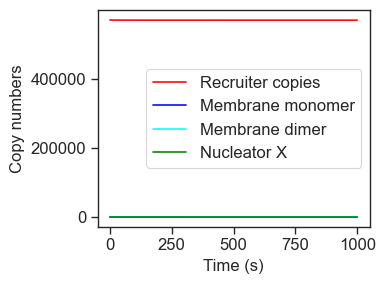

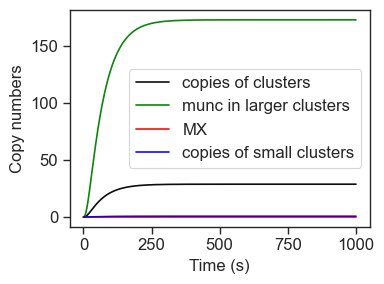

<Figure size 640x480 with 0 Axes>

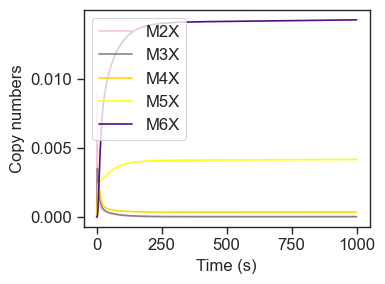

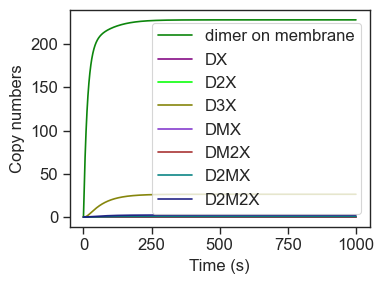

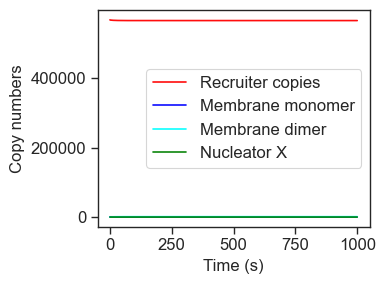

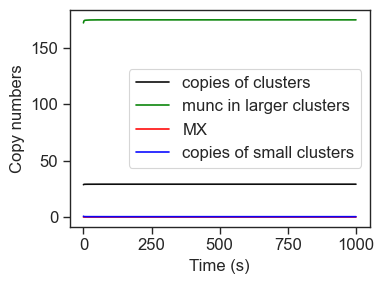

<Figure size 640x480 with 0 Axes>

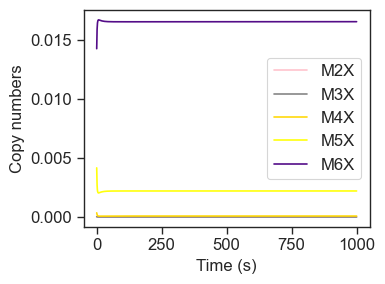

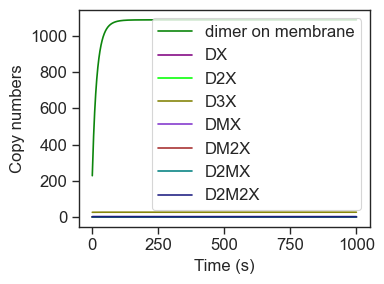

In [39]:
model.plot_freespecies_time(sol, figsize=(4, 3), fontsize=12, dpi=300)
model.plot_mycluster_time(sol, figsize=(4, 3), fontsize=12, dpi=300)
plt.figure()
model.plot_each_cluster_time(sol, figsize=(4, 3), fontsize=12, dpi=300)
model.plot_DX_cluster_time(sol, figsize=(4, 3), fontsize=12, dpi=300)
model.plot_freespecies_time(solPost, figsize=(4, 3), fontsize=12, dpi=300)
model.plot_mycluster_time(solPost, figsize=(4, 3), fontsize=12, dpi=300)
plt.figure()
model.plot_each_cluster_time(solPost, figsize=(4, 3), fontsize=12, dpi=300)
model.plot_DX_cluster_time(solPost, figsize=(4, 3), fontsize=12, dpi=300)
#m
#m

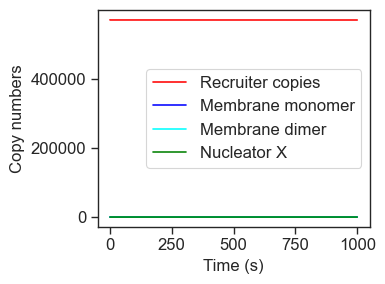

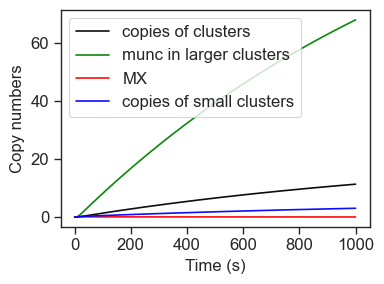

<Figure size 640x480 with 0 Axes>

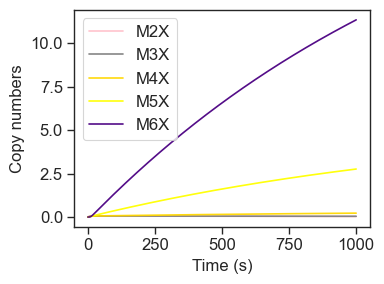

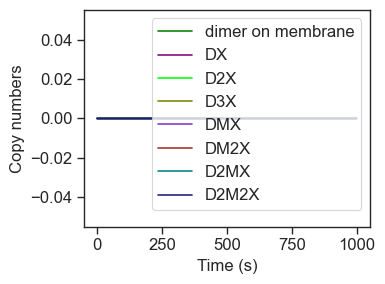

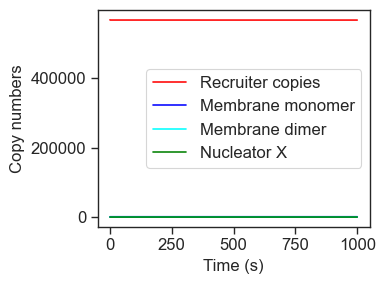

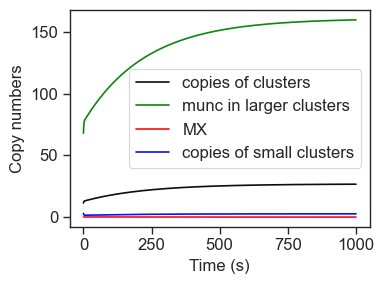

<Figure size 640x480 with 0 Axes>

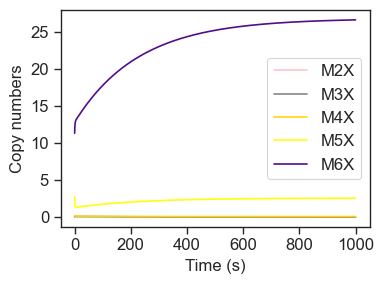

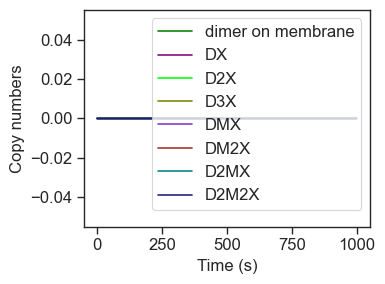

In [40]:
candidate_dc2a=list(candidate)
candidate_dc2a[2] = 0 #this sets kfmm to zero.
candidate_dc2a[12] = 0 #this sets kfdd to zero (no in cluster transition to 2M->D)
        
mut, mutPost = model.simulate(candidate_dc2a)
       
model.plot_freespecies_time(mut, figsize=(4, 3), fontsize=12, dpi=300)
model.plot_mycluster_time(mut, figsize=(4, 3), fontsize=12, dpi=300)
plt.figure()
model.plot_each_cluster_time(mut, figsize=(4, 3), fontsize=12, dpi=300)
model.plot_DX_cluster_time(mut, figsize=(4, 3), fontsize=12, dpi=300)
#m
model.plot_freespecies_time(mutPost, figsize=(4, 3), fontsize=12, dpi=300)
model.plot_mycluster_time(mutPost, figsize=(4, 3), fontsize=12, dpi=300)
plt.figure()
model.plot_each_cluster_time(mutPost, figsize=(4, 3), fontsize=12, dpi=300)
model.plot_DX_cluster_time(mutPost, figsize=(4, 3), fontsize=12, dpi=300)
#m

In [41]:
print(model.timePoints[1])

0.5


# Now generate plots and save to file for the paper

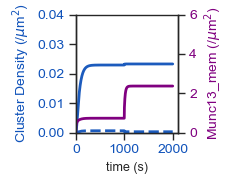

In [42]:
model.plot_time_resolved_density(sol, solPost,f"WT_{unique_id}_{whichRow}")

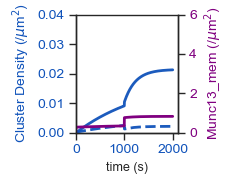

In [43]:
#Plot the same thing for the C2A mutant.
model.plot_time_resolved_density(mut, mutPost, f"C2A_{unique_id}_{whichRow}")

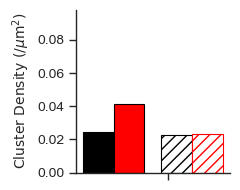

In [44]:
#plot cluster density as a bar plot
model.plot_density_vs_exp(sol, solPost, f"WT_{unique_id}_{whichRow}", whichExp='WT')

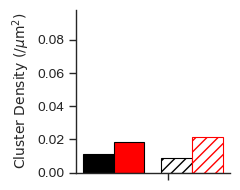

In [45]:
#plot cluster density as a bar plot
model.plot_density_vs_exp(mut, mutPost, f"C2A_{unique_id}_{whichRow}", whichExp='C2A')

In [46]:
print(D_metrics.iloc[whichRow])

D           0.037284
Dpost       0.034963
C2AD        0.064482
C2ADpost    0.066725
Name: 0, dtype: float64


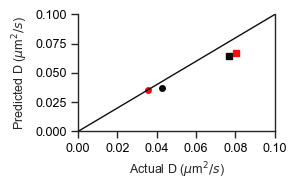

In [47]:
#make a plot that shows actual and predicted diffusion constants for

model.plot_diffusion_vs_exp(D_metrics, whichRow, fileStr=f"_{unique_id}_")


sizes pre stim, and sum:  [np.float64(0.3078276239815862), np.float64(0.4994131276091714), np.float64(0.18870813016927013)]
sizes POST stim, and sum:  [np.float64(0.20724850833538924), np.float64(0.7331971114275995), np.float64(0.058996452085881834)]


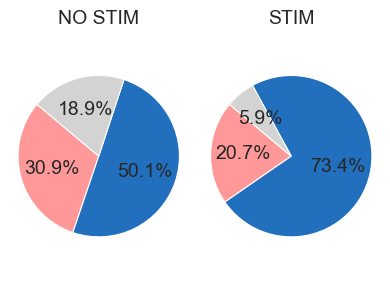

sizes pre stim, and sum:  [np.float64(0.8037360201728215), np.float64(0.0), np.float64(0.16092651165262256)]
sizes POST stim, and sum:  [np.float64(0.8321048876472567), np.float64(0.15521742452537407)]


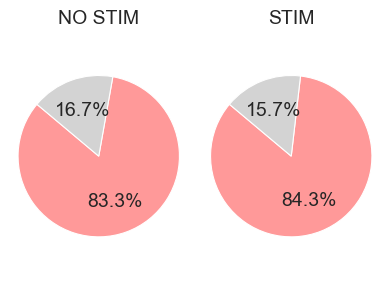

In [48]:
#create pie charts.
model.pie_charts(sol, solPost, [4,3], f"WT_{unique_id}_{whichRow}")
#create pie charts of the mutant.
model.pie_charts(mut, mutPost, [4,3], f"C2A_{unique_id}_{whichRow}")

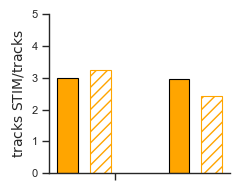

In [49]:
#plot the increase in tracks, experiment vs simulation
model.plot_track_increase_vs_exp(sol, solPost, mut, mutPost, fileStr=f"{unique_id}_row_{whichRow}", figsize=(2.5, 2))
       

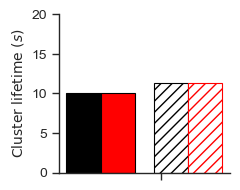

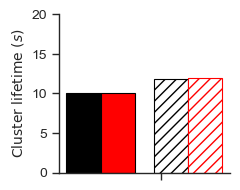

In [50]:
#create a plot comparing the lifetimes before and after stimulation
model.plot_lifetime_vs_exp(candidate, sol, solPost, f"{unique_id}_WT_{whichRow}")
#create the plot fot eh C2A mutant
model.plot_lifetime_vs_exp(candidate_dc2a, mut, mutPost, f"{unique_id}_C2A_{whichRow}")

# For the cluster centroids, also evaluate all the key metrics and save to file

In [51]:
#Set up the dataframe with the first solution results
just_parms=sorted_centroid[param_cols]
candidate=just_parms.iloc[0].values
print(candidate)
colWT = ['tau56','tau56Post', 'densPre','densPost','stimFact','percClust','percCPost','percDimer','percDPost','SSval','SSvalPost']
colC2A = ['C2Atau56','C2Atau56Post', 'C2AdensPre','C2AdensPost','C2AstimFact','C2ApercClust','C2ApercCPost','C2ApercDimer','C2ApercDPost','C2ASSval','C2ASSvalPost']

colD = ['D', 'Dpost', 'C2AD', 'C2ADpost']
[metricsWT,metricsC2A, metricsD]=model.compute_all_metrics(candidate)
print(len(metricsWT))
clus_metrics = pd.DataFrame([metricsWT], columns=colWT)
C2Aclus_metrics = pd.DataFrame([metricsC2A], columns=colC2A)
Dclus_metrics = pd.DataFrame([metricsD], columns = colD)

[2.29478635e-02 8.27040899e-02 1.29548142e+00 8.80985031e-02
 1.19810715e+00 1.04352383e-01 4.81579825e+00 1.27633252e-01
 2.19889816e-02 1.70144776e-01 1.63123262e+00 1.43565234e-03
 6.43102227e-02 1.01124027e+00 1.09534980e+01 1.95252806e-03
 2.60674757e+03 2.32026740e-02 3.50678294e-50]
11


In [52]:
#Now iterate over all other solutions in the sorted_centroid array
#add them to the dataframe.
for i in np.arange(1,len(just_parms)):
    candidate=just_parms.iloc[i].values
    print(candidate)
    [metricsWT,metricsC2A, metricsD]=model.compute_all_metrics(candidate)
    clus_metrics.loc[len(clus_metrics)] = metricsWT
    C2Aclus_metrics.loc[len(C2Aclus_metrics)] = metricsC2A
    Dclus_metrics.loc[len(Dclus_metrics)] = metricsD

print(clus_metrics)
print(Dclus_metrics)

[2.66972742e+00 2.92717896e-02 1.34388922e+00 5.28846181e-02
 7.60877775e-01 9.87014393e+00 6.68431270e+00 5.08295542e-02
 3.19589591e-01 9.47591130e-01 2.96222912e+00 4.33757977e-02
 7.68279051e-02 5.17043626e-01 5.39051542e+01 5.19437588e-03
 1.11440537e+00 3.03794297e-02 7.23013402e-50]
[3.79099463e-01 1.18242534e+00 2.60912990e+00 1.77604815e-01
 4.01660822e-02 4.79157704e-01 6.12047374e+00 1.12904346e-01
 9.28769531e-01 8.53592672e+00 1.03196280e+00 1.38422969e-01
 2.75121838e-01 2.73482129e+00 3.12955699e+00 7.48626471e-03
 3.92573026e+02 2.62049306e-02 2.13293174e-50]
[8.30254990e-03 9.18469651e-03 3.76670642e+00 1.85551334e-01
 1.04628335e-02 1.01276375e-01 5.44052065e+00 1.86628473e-01
 2.17248162e-01 1.34186404e+00 6.23227194e-01 1.79717558e-02
 1.90020770e-01 1.73708105e+00 2.91188156e+00 9.55821829e-03
 7.29179938e+01 3.89568966e-02 1.44991145e-50]
[2.19197992e+00 2.39320120e+00 6.62032332e+00 1.78893946e-01
 1.53514263e-01 6.49199552e-02 4.52284778e+00 5.25377618e-01
 2.55

In [53]:
print(C2Aclus_metrics)

     C2Atau56  C2Atau56Post  C2AdensPre  C2AdensPost  C2AstimFact  \
0    4.803085      4.803085    0.017729     0.021265     2.777438   
1    6.621176      6.641475    0.013758     0.026204     2.514252   
2    8.575834      8.582729    0.022175     0.024969     2.519182   
3    8.543481      8.588357    0.013806     0.034072     2.632722   
4    5.948354      5.948354    0.013770     0.025782     2.697865   
5    4.893891      4.893891    0.016780     0.020291     3.029516   
6    6.629453      6.629490    0.017363     0.019924     3.582880   
7    8.760091      8.760091    0.019101     0.020203     1.909459   
8    4.964176      4.964176    0.018796     0.020767     2.625382   
9    4.899198      4.899771    0.020694     0.023659     3.692583   
10   5.969439      5.969440    0.014168     0.017694     3.184040   
11   5.484380      5.484380    0.019080     0.023007     3.181301   
12   8.586794      8.586794    0.016411     0.019382     2.944578   
13   7.112632      7.112632    0.0

In [54]:
print(Dclus_metrics)

           D     Dpost      C2AD  C2ADpost
0   0.037188  0.035328  0.070758  0.076560
1   0.034986  0.034959  0.058376  0.066921
2   0.036161  0.032468  0.068487  0.075225
3   0.036698  0.032143  0.068211  0.070529
4   0.032825  0.030290  0.070608  0.075163
5   0.039644  0.036812  0.073284  0.077710
6   0.036248  0.033157  0.074195  0.078334
7   0.041782  0.038295  0.072870  0.076232
8   0.043623  0.035349  0.075311  0.078178
9   0.038552  0.034338  0.073816  0.078278
10  0.034858  0.032149  0.072204  0.077454
11  0.041954  0.036496  0.073772  0.077943
12  0.038971  0.035464  0.075069  0.078191
13  0.036348  0.032481  0.074863  0.078409
14  0.035585  0.032403  0.074010  0.078324
15  0.042590  0.039921  0.073572  0.076414
16  0.037583  0.034119  0.076769  0.078136
17  0.043640  0.040256  0.074116  0.077848
18  0.037930  0.032170  0.074964  0.077968
19  0.050584  0.043408  0.073864  0.078129
20  0.030924  0.029048  0.076410  0.079154
21  0.050896  0.041872  0.077706  0.079155
22  0.04424

In [55]:
print(C2Aclus_metrics)

     C2Atau56  C2Atau56Post  C2AdensPre  C2AdensPost  C2AstimFact  \
0    4.803085      4.803085    0.017729     0.021265     2.777438   
1    6.621176      6.641475    0.013758     0.026204     2.514252   
2    8.575834      8.582729    0.022175     0.024969     2.519182   
3    8.543481      8.588357    0.013806     0.034072     2.632722   
4    5.948354      5.948354    0.013770     0.025782     2.697865   
5    4.893891      4.893891    0.016780     0.020291     3.029516   
6    6.629453      6.629490    0.017363     0.019924     3.582880   
7    8.760091      8.760091    0.019101     0.020203     1.909459   
8    4.964176      4.964176    0.018796     0.020767     2.625382   
9    4.899198      4.899771    0.020694     0.023659     3.692583   
10   5.969439      5.969440    0.014168     0.017694     3.184040   
11   5.484380      5.484380    0.019080     0.023007     3.181301   
12   8.586794      8.586794    0.016411     0.019382     2.944578   
13   7.112632      7.112632    0.0

In [56]:
#print these solutions to file
allCentroidParmFile = f"{dir}/Centroid_solutions_Dterm_parameters_{unique_id}.csv"

sorted_centroid.to_csv(allCentroidParmFile, index=False)
clus_metrics.to_csv(f"{dir}/Centroid_solutions_Dterm_WT_{unique_id}.csv")
C2Aclus_metrics.to_csv(f"{dir}/Centroid_solutions_Dterm_C2A_{unique_id}.csv")
Dclus_metrics.to_csv(f"{dir}/Centroid_solutions_Dterm_Diffusion_{unique_id}.csv")

In [57]:
#filter solutions that have the correct trend with diffusion.
storeID=[]
for idx, row in D_metrics.iterrows():
    #print(f"Row {idx}: {row.to_dict()}")
    # You can access individual columns like row['D'], row['Dpost'], etc.
    ratio=row['D']/row['Dpost']
    
    if ratio>1.1:
        storeID.append(idx)

storeID=np.array(storeID)
print(storeID)
subset=selected_solutions.iloc[storeID]
subset.to_csv(f"{dir}/parameter_solutions_Dslows_{unique_id}.csv", index=False)


[2 3]


Total solutions loaded: 5
Using top 50% by Fitness -> 2 solutions.
Saved summary to: /Users/margaret/Dropbox/r2025/Munc13/IMAGES/sensitivityDterm_8888.png
Total solutions loaded: 2
Using top 50% by Fitness -> 1 solutions.
Saved summary to: /Users/margaret/Dropbox/r2025/Munc13/IMAGES/sensitivityDterm_8888_Dslows.png


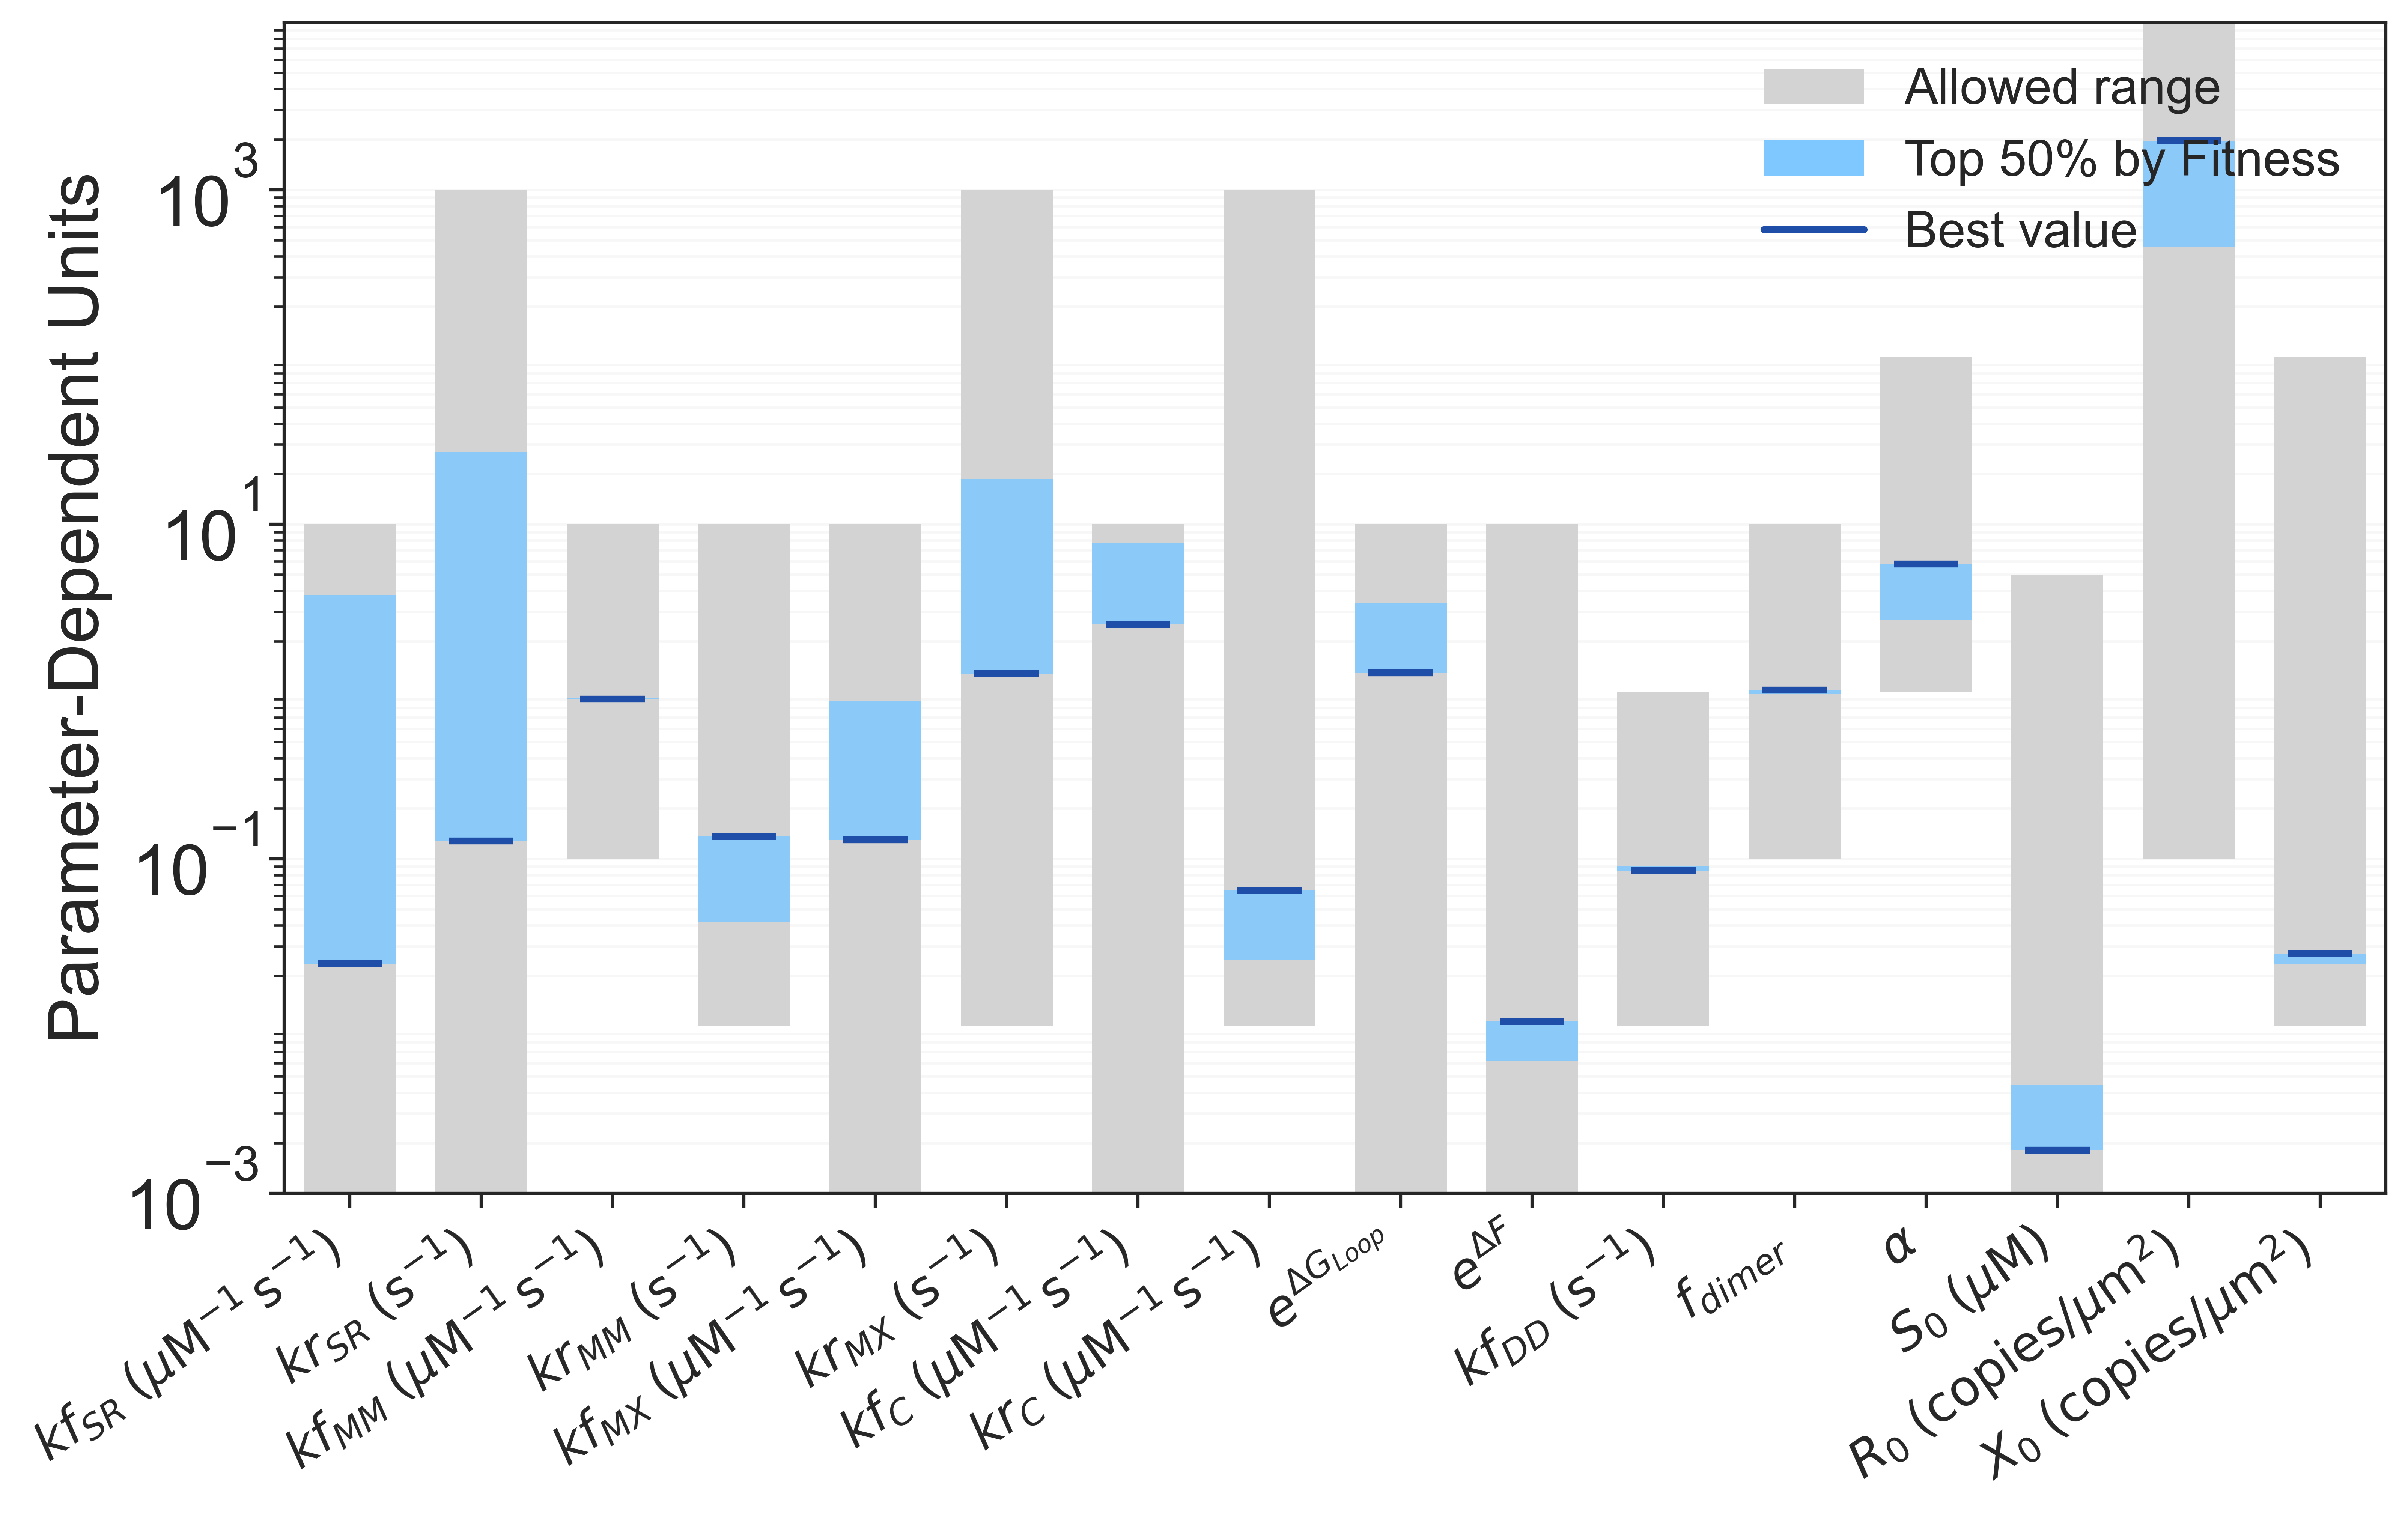

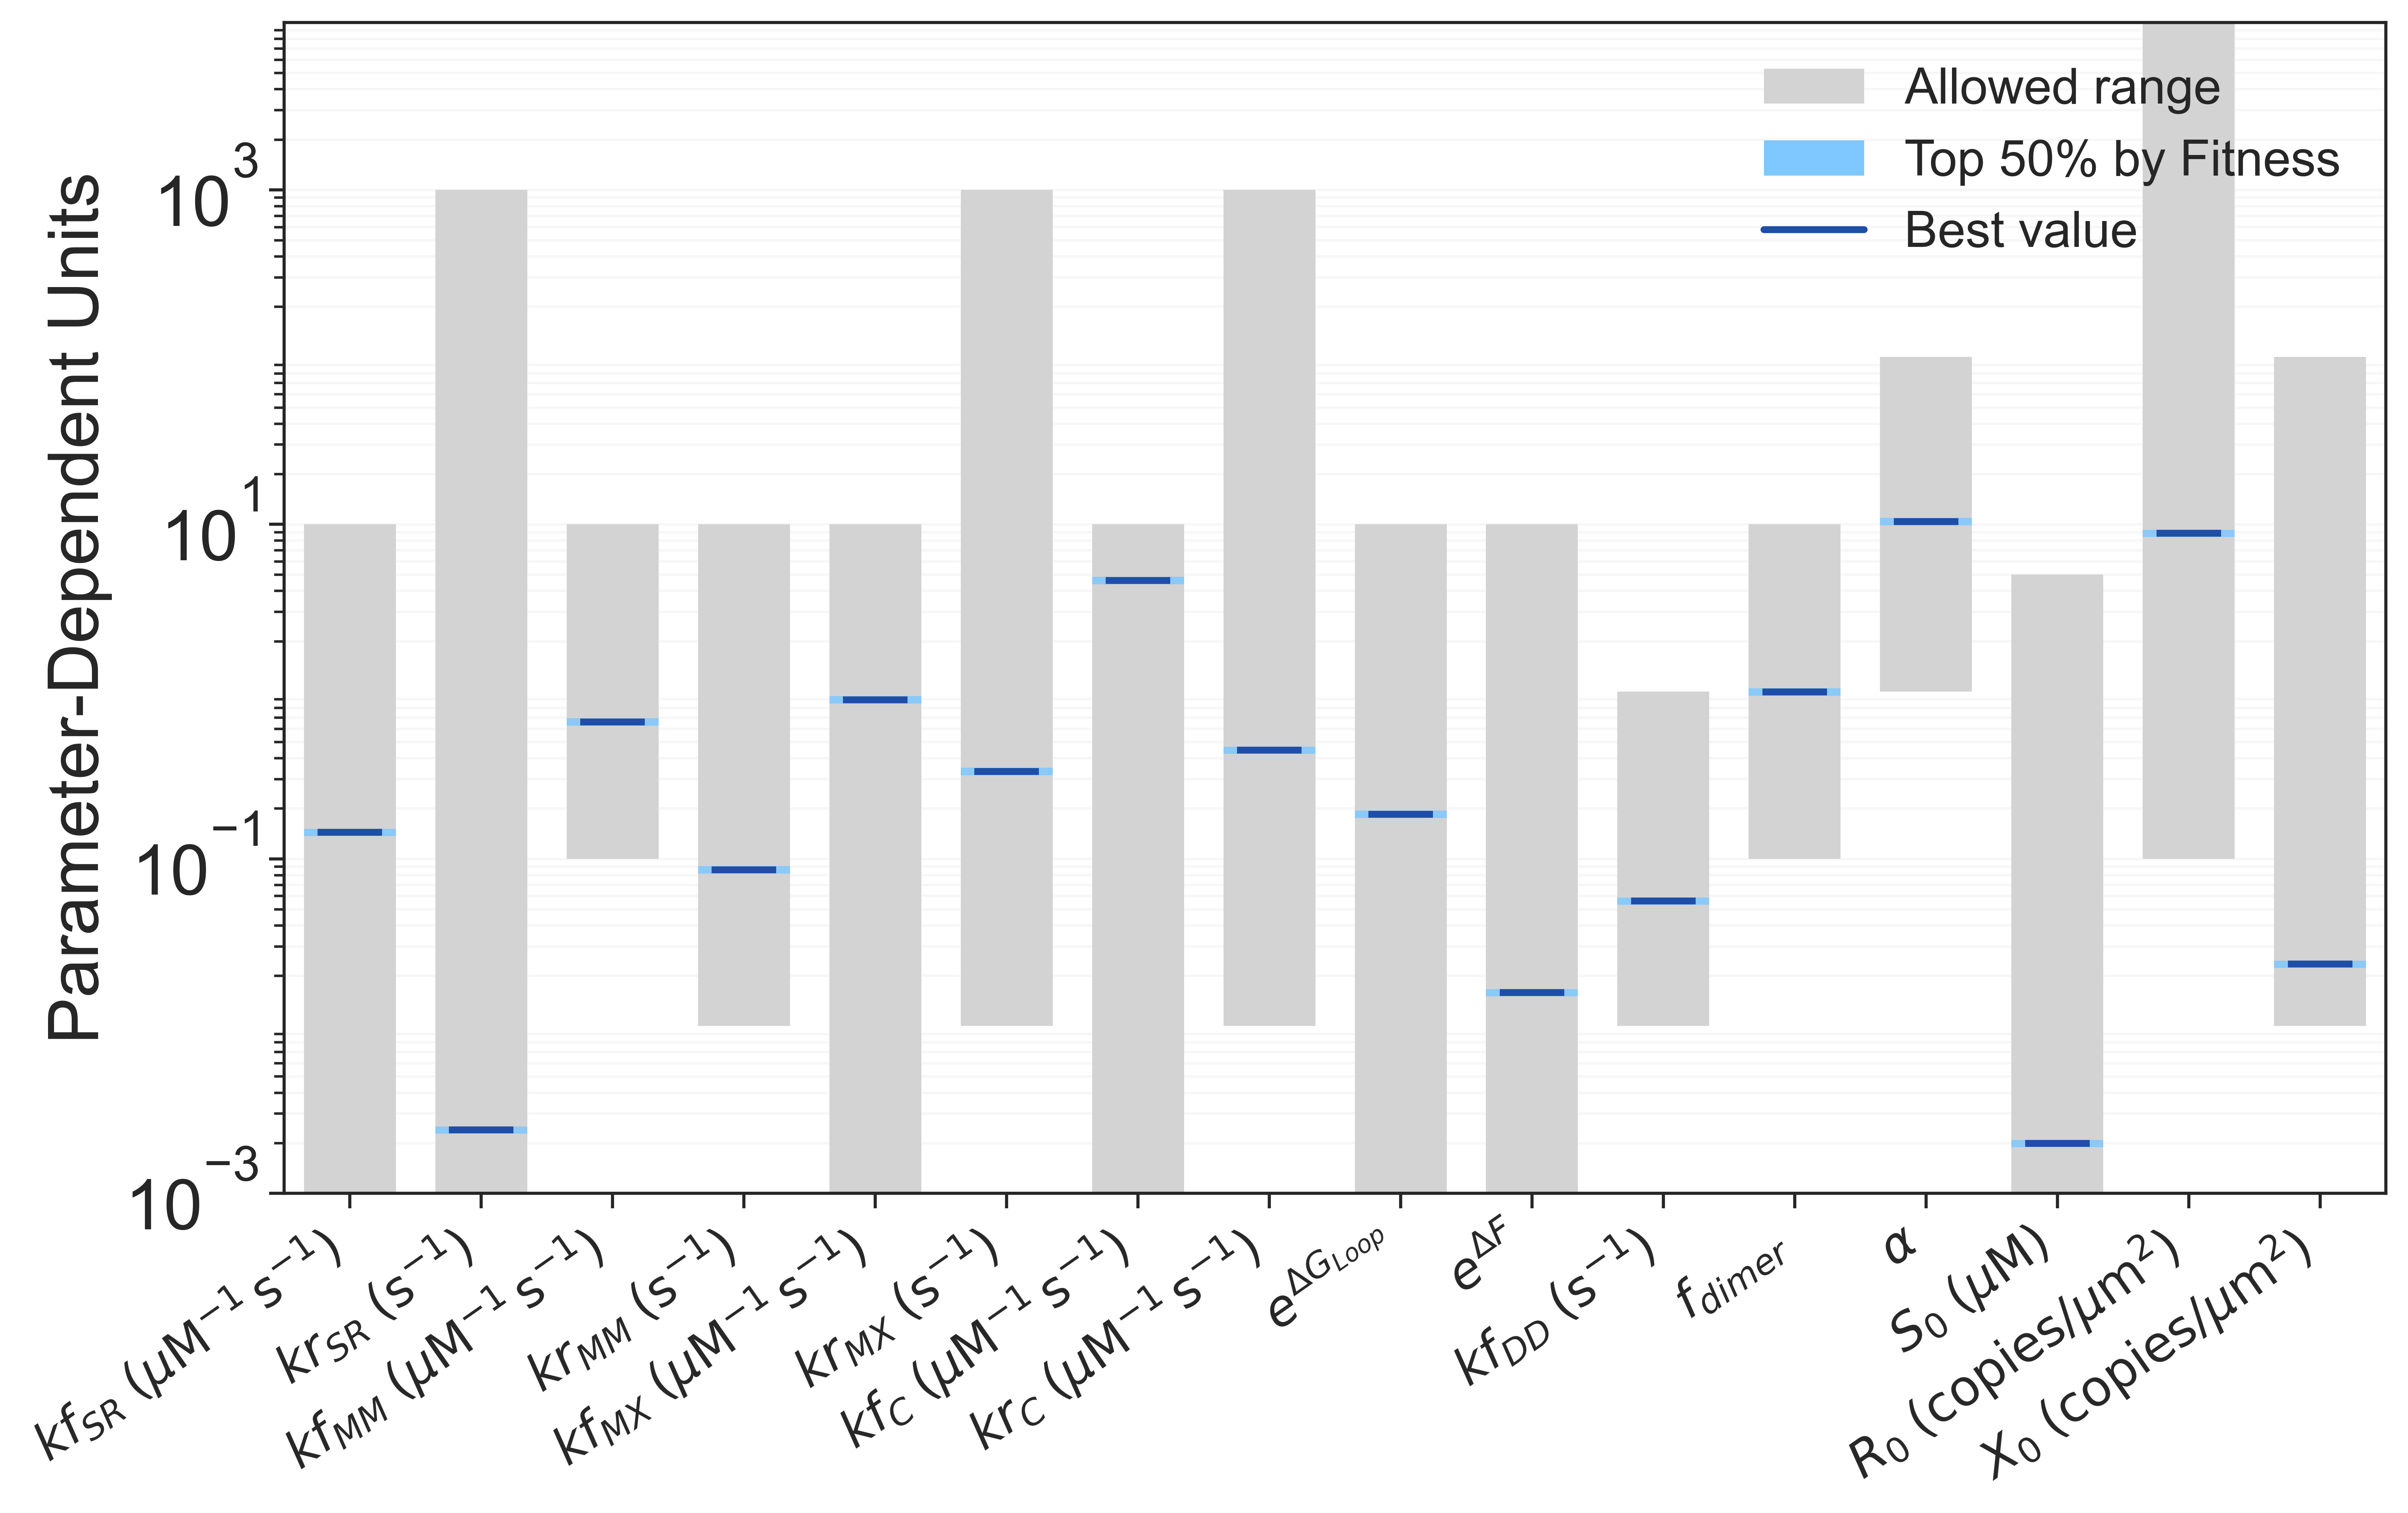

In [58]:
#plot paramter ranges for top solutions, for clusters, 
#and also just for solutions where mobility is good
model.plot_parameter_ranges_summary(parameter_ranges=parameter_ranges, percent=50, save_path=f"{imageDir}/sensitivityDterm_{unique_id}.png",inputFile=f"{dir}/Top11_solutions_Dterm_parameters_{unique_id}.csv")
model.plot_parameter_ranges_summary(parameter_ranges=parameter_ranges, percent=50, save_path=f"{imageDir}/sensitivityDterm_{unique_id}_Dslows.png",inputFile=f"{dir}/parameter_solutions_Dslows_{unique_id}.csv")


In [59]:
#filter solutions that have the correct trend with diffusion.
storeID2=[]
for idx, row in Dclus_metrics.iterrows():
    #print(f"Row {idx}: {row.to_dict()}")
    # You can access individual columns like row['D'], row['Dpost'], etc.
    ratio=row['D']/row['Dpost']
    
    if ratio>1.1:
        storeID2.append(idx)

storeID2=np.array(storeID2)
print(storeID2)
subset=sorted_centroid.iloc[storeID2]
parmFileSave = f"{dir}/centroid_parameter_solutions_Dslows_{unique_id}.csv"
subset.to_csv(parmFileSave, index=False)


[ 2  3  8  9 11 13 16 18 19 21 22 23 24 25 26]


Total solutions loaded: 30
Using top 50% by Fitness -> 15 solutions.
Saved summary to: /Users/margaret/Dropbox/r2025/Munc13/IMAGES/Data_for_plots/sensitivity_centroid_8888.png
Total solutions loaded: 15
Using top 50% by Fitness -> 7 solutions.
Saved summary to: /Users/margaret/Dropbox/r2025/Munc13/IMAGES/Data_for_plots/sensitivity_centroid_Dslows_8888.png


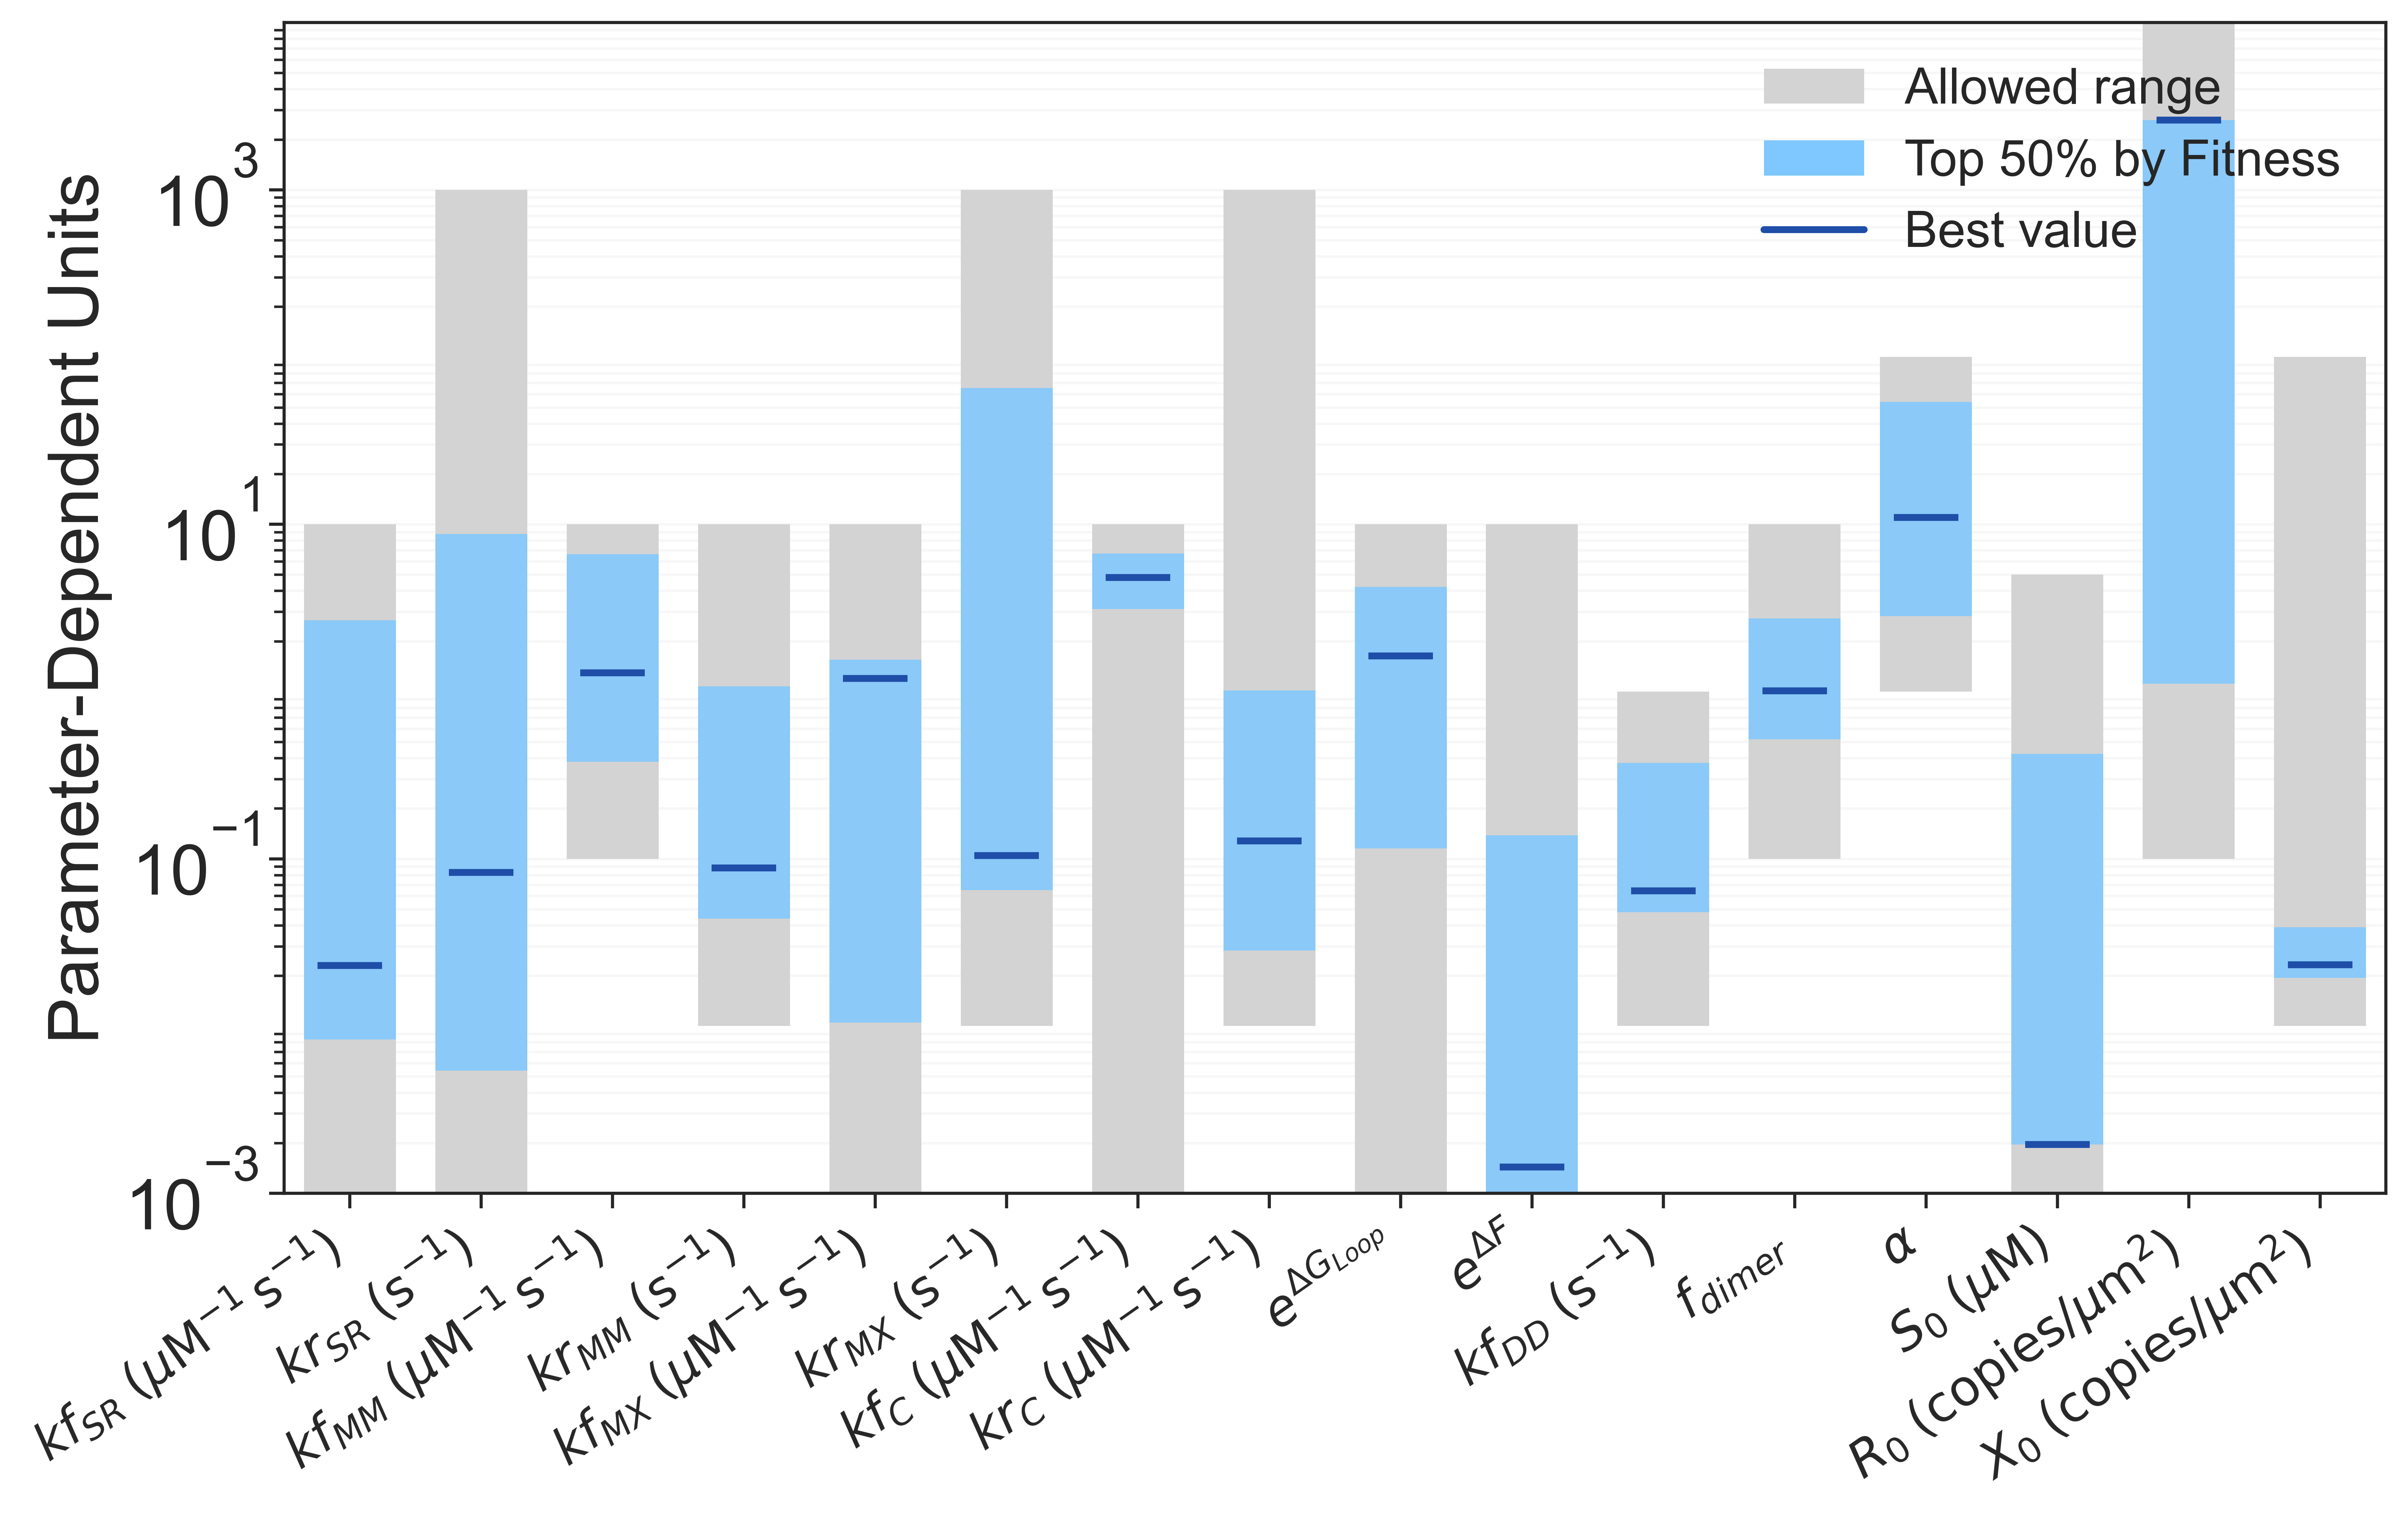

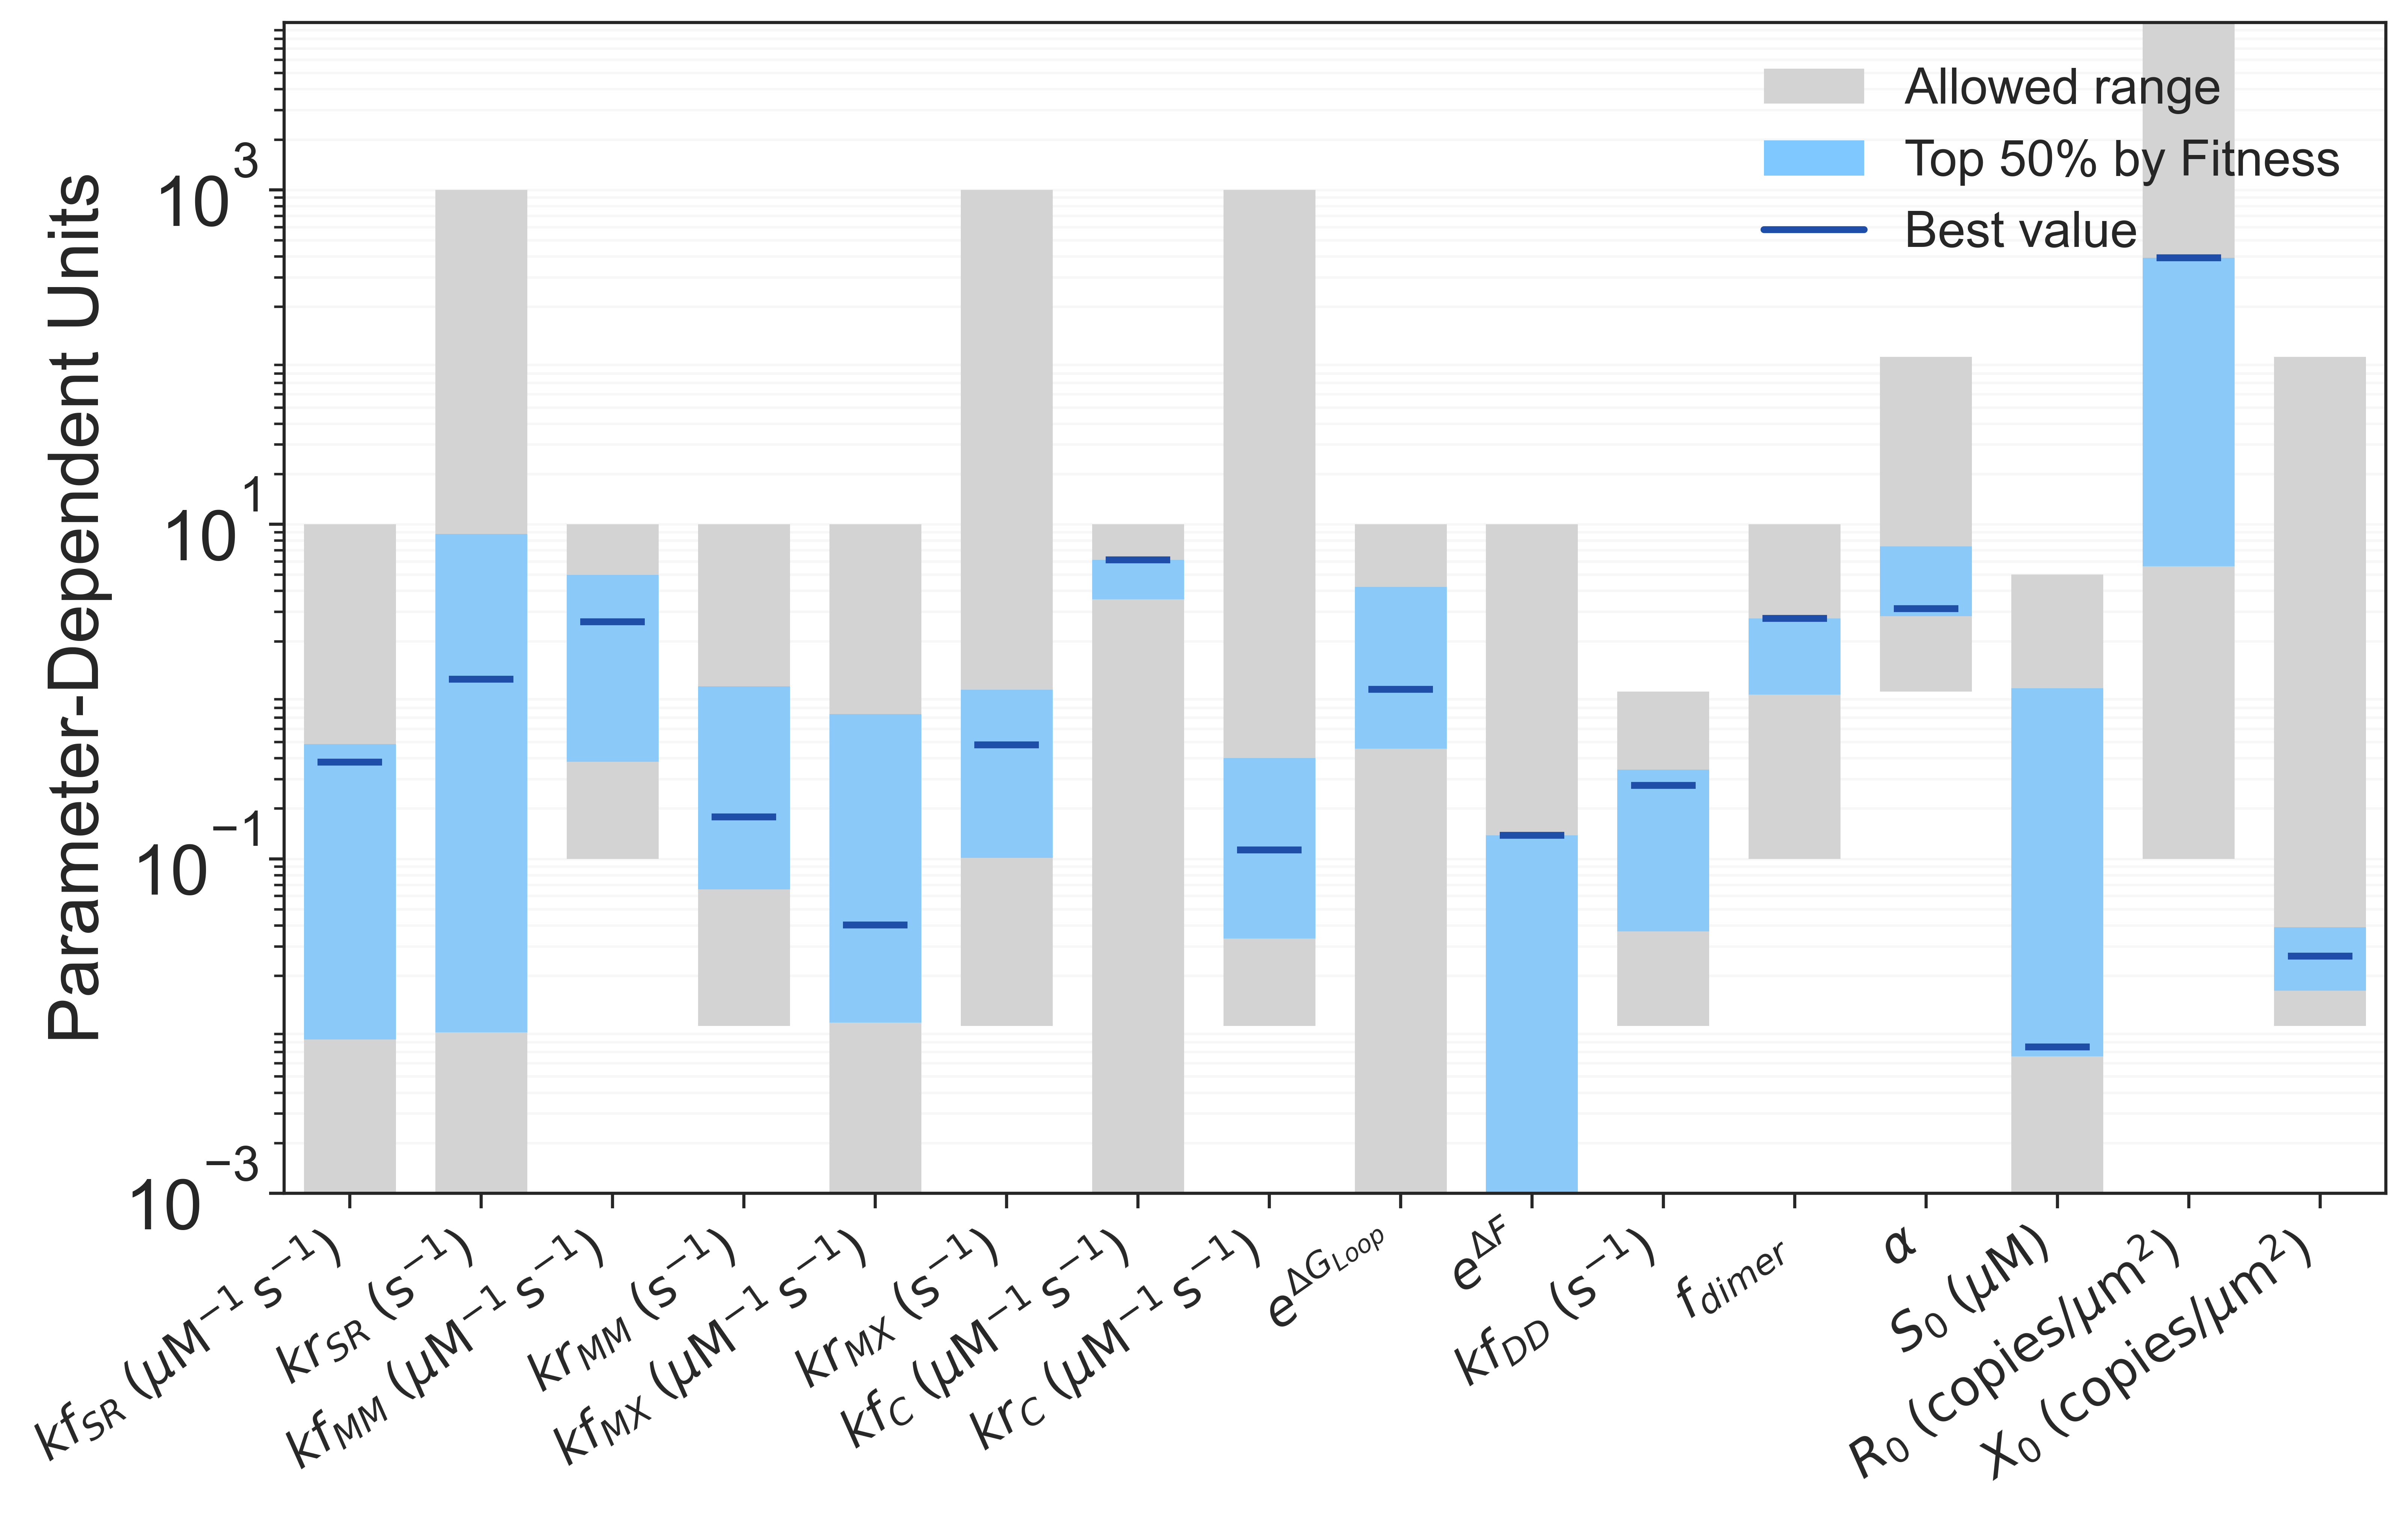

In [60]:
#now create the sensitivity plots based on all the clusters
model.plot_parameter_ranges_summary(parameter_ranges=parameter_ranges, percent=50, save_path=f"{dir}/sensitivity_centroid_{unique_id}.png",inputFile=allCentroidParmFile)
model.plot_parameter_ranges_summary(parameter_ranges=parameter_ranges, percent=50, save_path=f"{dir}/sensitivity_centroid_Dslows_{unique_id}.png",inputFile=parmFileSave)


# distribution of sampled KD values from top 11

Total solutions loaded: 5
Using top 50% by Fitness -> 2 solutions.
p:  kDsr
best_row        kDsr      kDmm      kDmx      kDc        kDq
0  5.430076  0.150938  9.885899  0.02567  21.065214
p:  kDmm
best_row        kDsr      kDmm      kDmx      kDc        kDq
0  5.430076  0.150938  9.885899  0.02567  21.065214
p:  kDmx
best_row        kDsr      kDmm      kDmx      kDc        kDq
0  5.430076  0.150938  9.885899  0.02567  21.065214
p:  kDc
best_row        kDsr      kDmm      kDmx      kDc        kDq
0  5.430076  0.150938  9.885899  0.02567  21.065214
p:  kDq
best_row        kDsr      kDmm      kDmx      kDc        kDq
0  5.430076  0.150938  9.885899  0.02567  21.065214


/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), ti

Saved summary to: /Users/margaret/Dropbox/r2025/Munc13/IMAGES/sensitivity_KD_Top11_8888.png
Total solutions loaded: 2
Using top 50% by Fitness -> 1 solutions.
p:  kDsr
best_row        kDsr      kDmm      kDmx       kDc       kDq
0  0.016631  0.130649  0.372639  0.096528  13.61272
p:  kDmm
best_row        kDsr      kDmm      kDmx       kDc       kDq
0  0.016631  0.130649  0.372639  0.096528  13.61272
p:  kDmx
best_row        kDsr      kDmm      kDmx       kDc       kDq
0  0.016631  0.130649  0.372639  0.096528  13.61272
p:  kDc
best_row        kDsr      kDmm      kDmx       kDc       kDq
0  0.016631  0.130649  0.372639  0.096528  13.61272
p:  kDq
best_row        kDsr      kDmm      kDmx       kDc       kDq
0  0.016631  0.130649  0.372639  0.096528  13.61272


/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), ti

Saved summary to: /Users/margaret/Dropbox/r2025/Munc13/IMAGES/sensitivity_KD_Top11_Dslows_8888.png


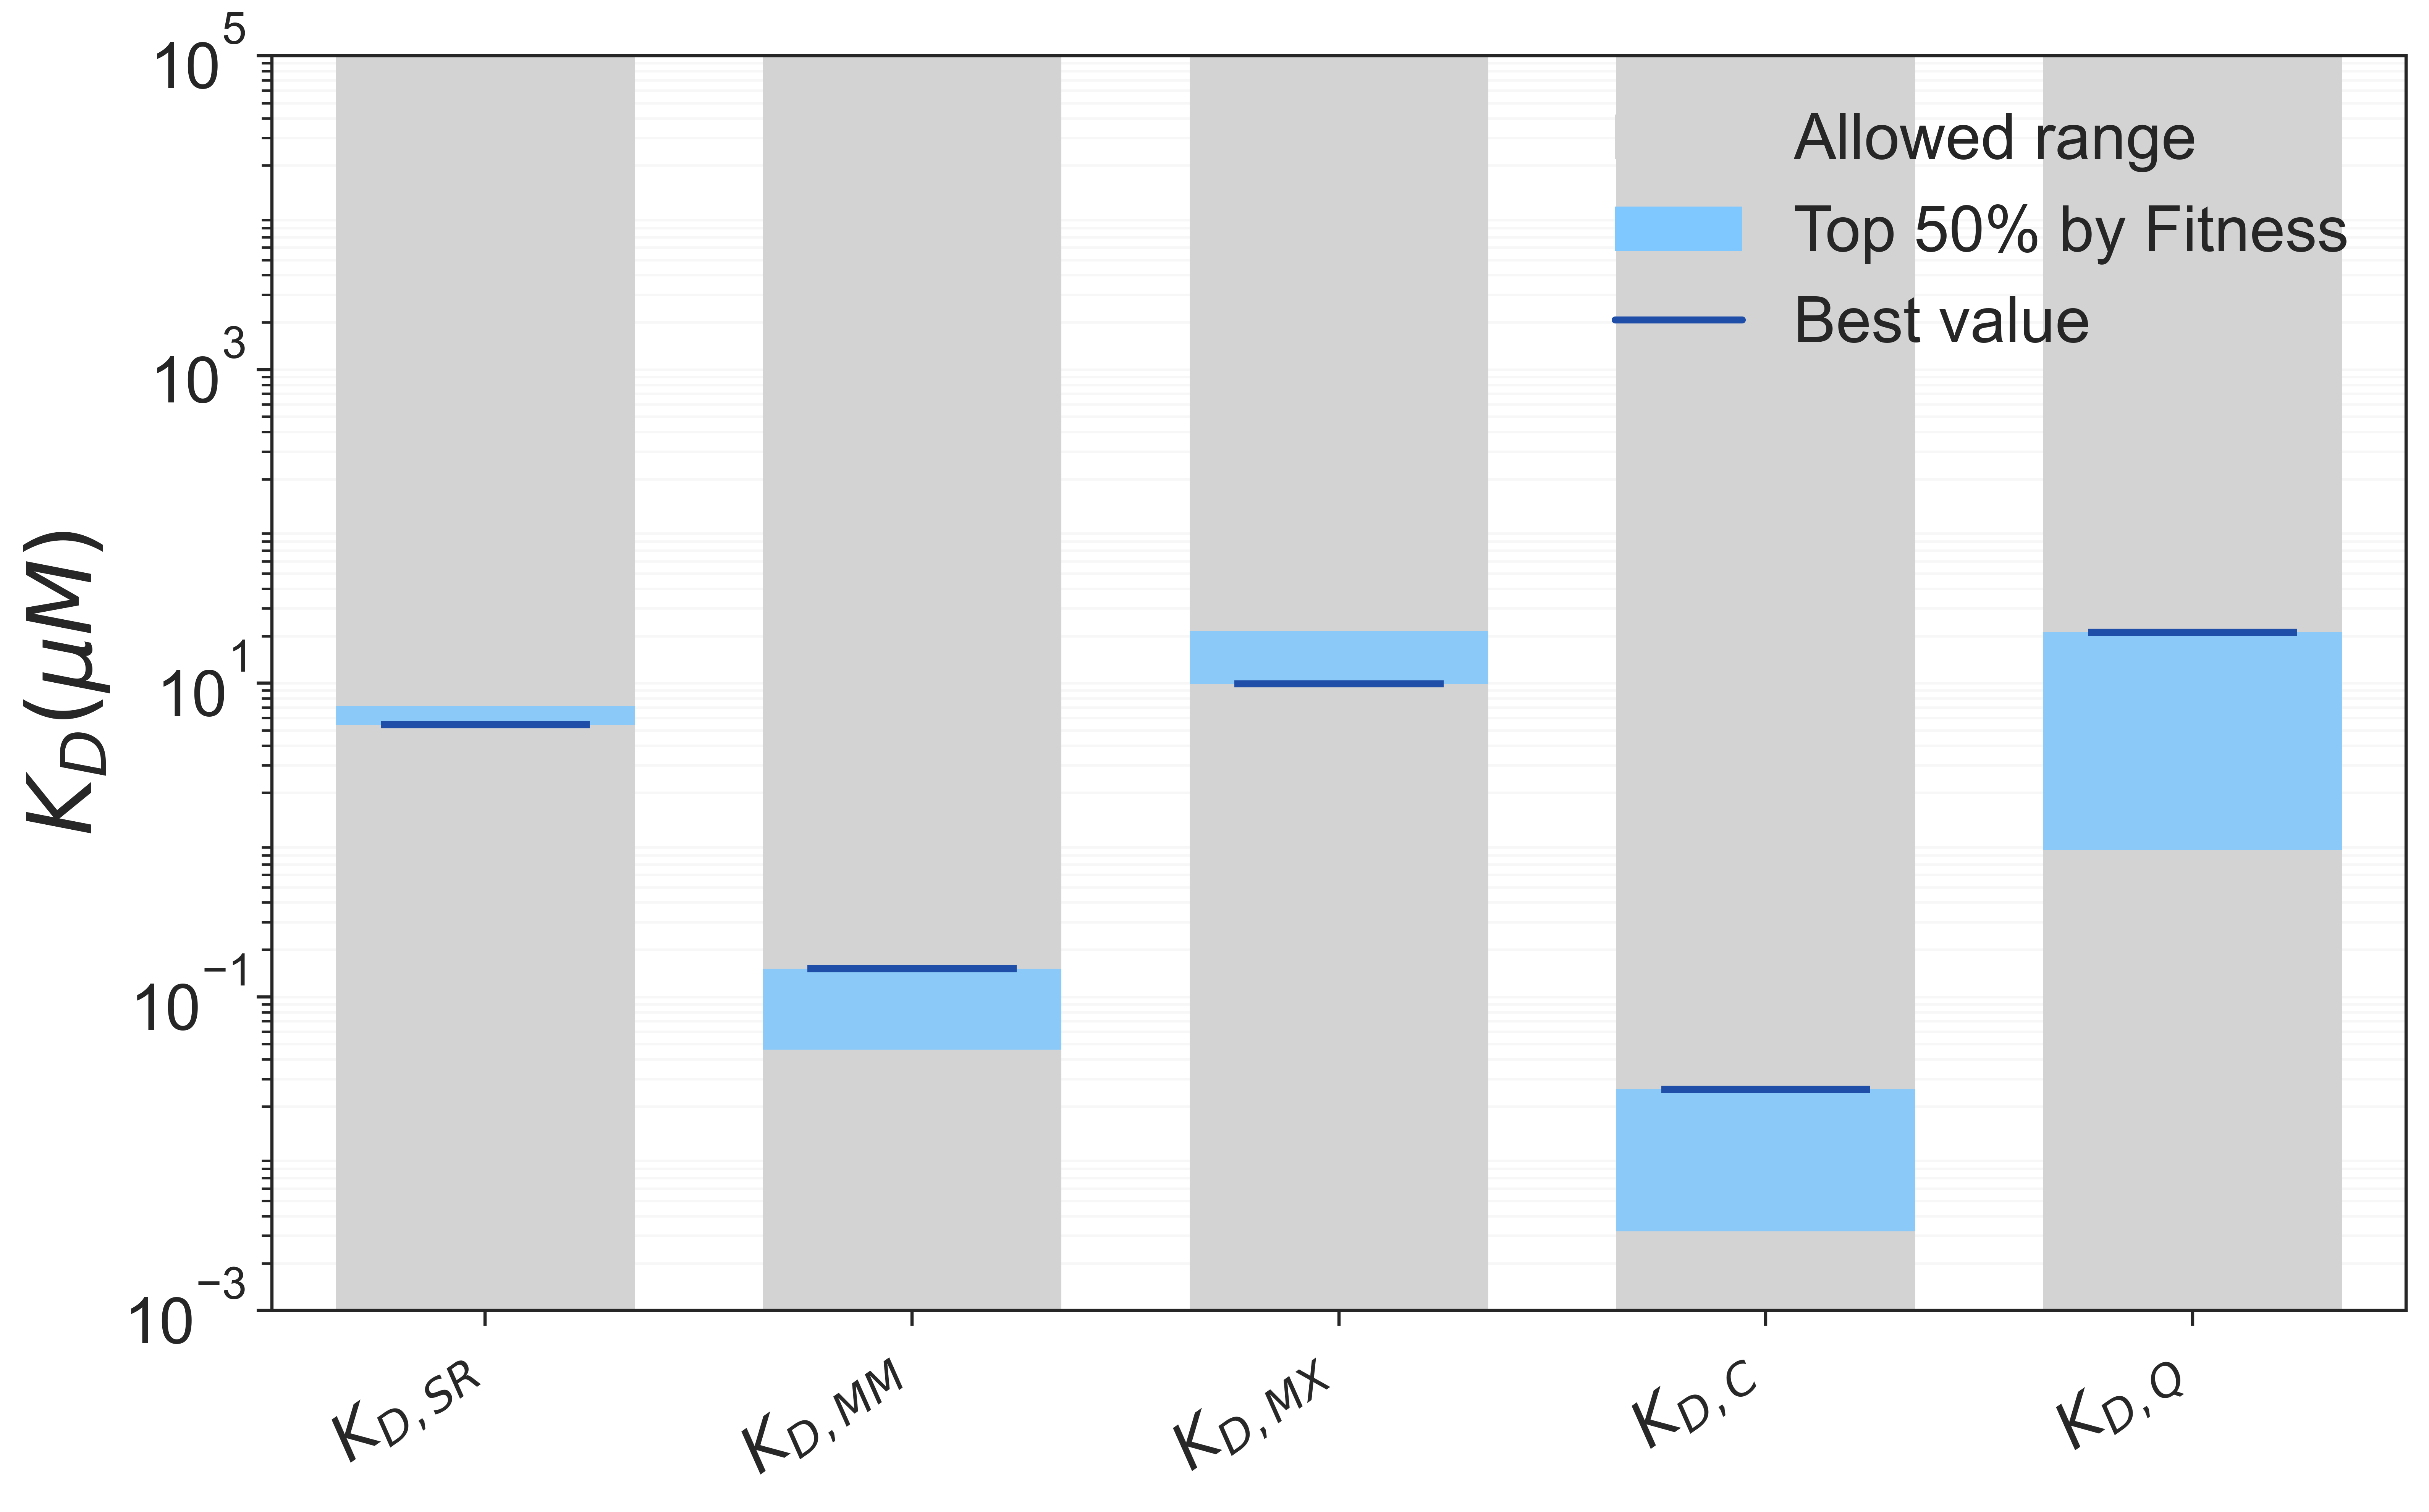

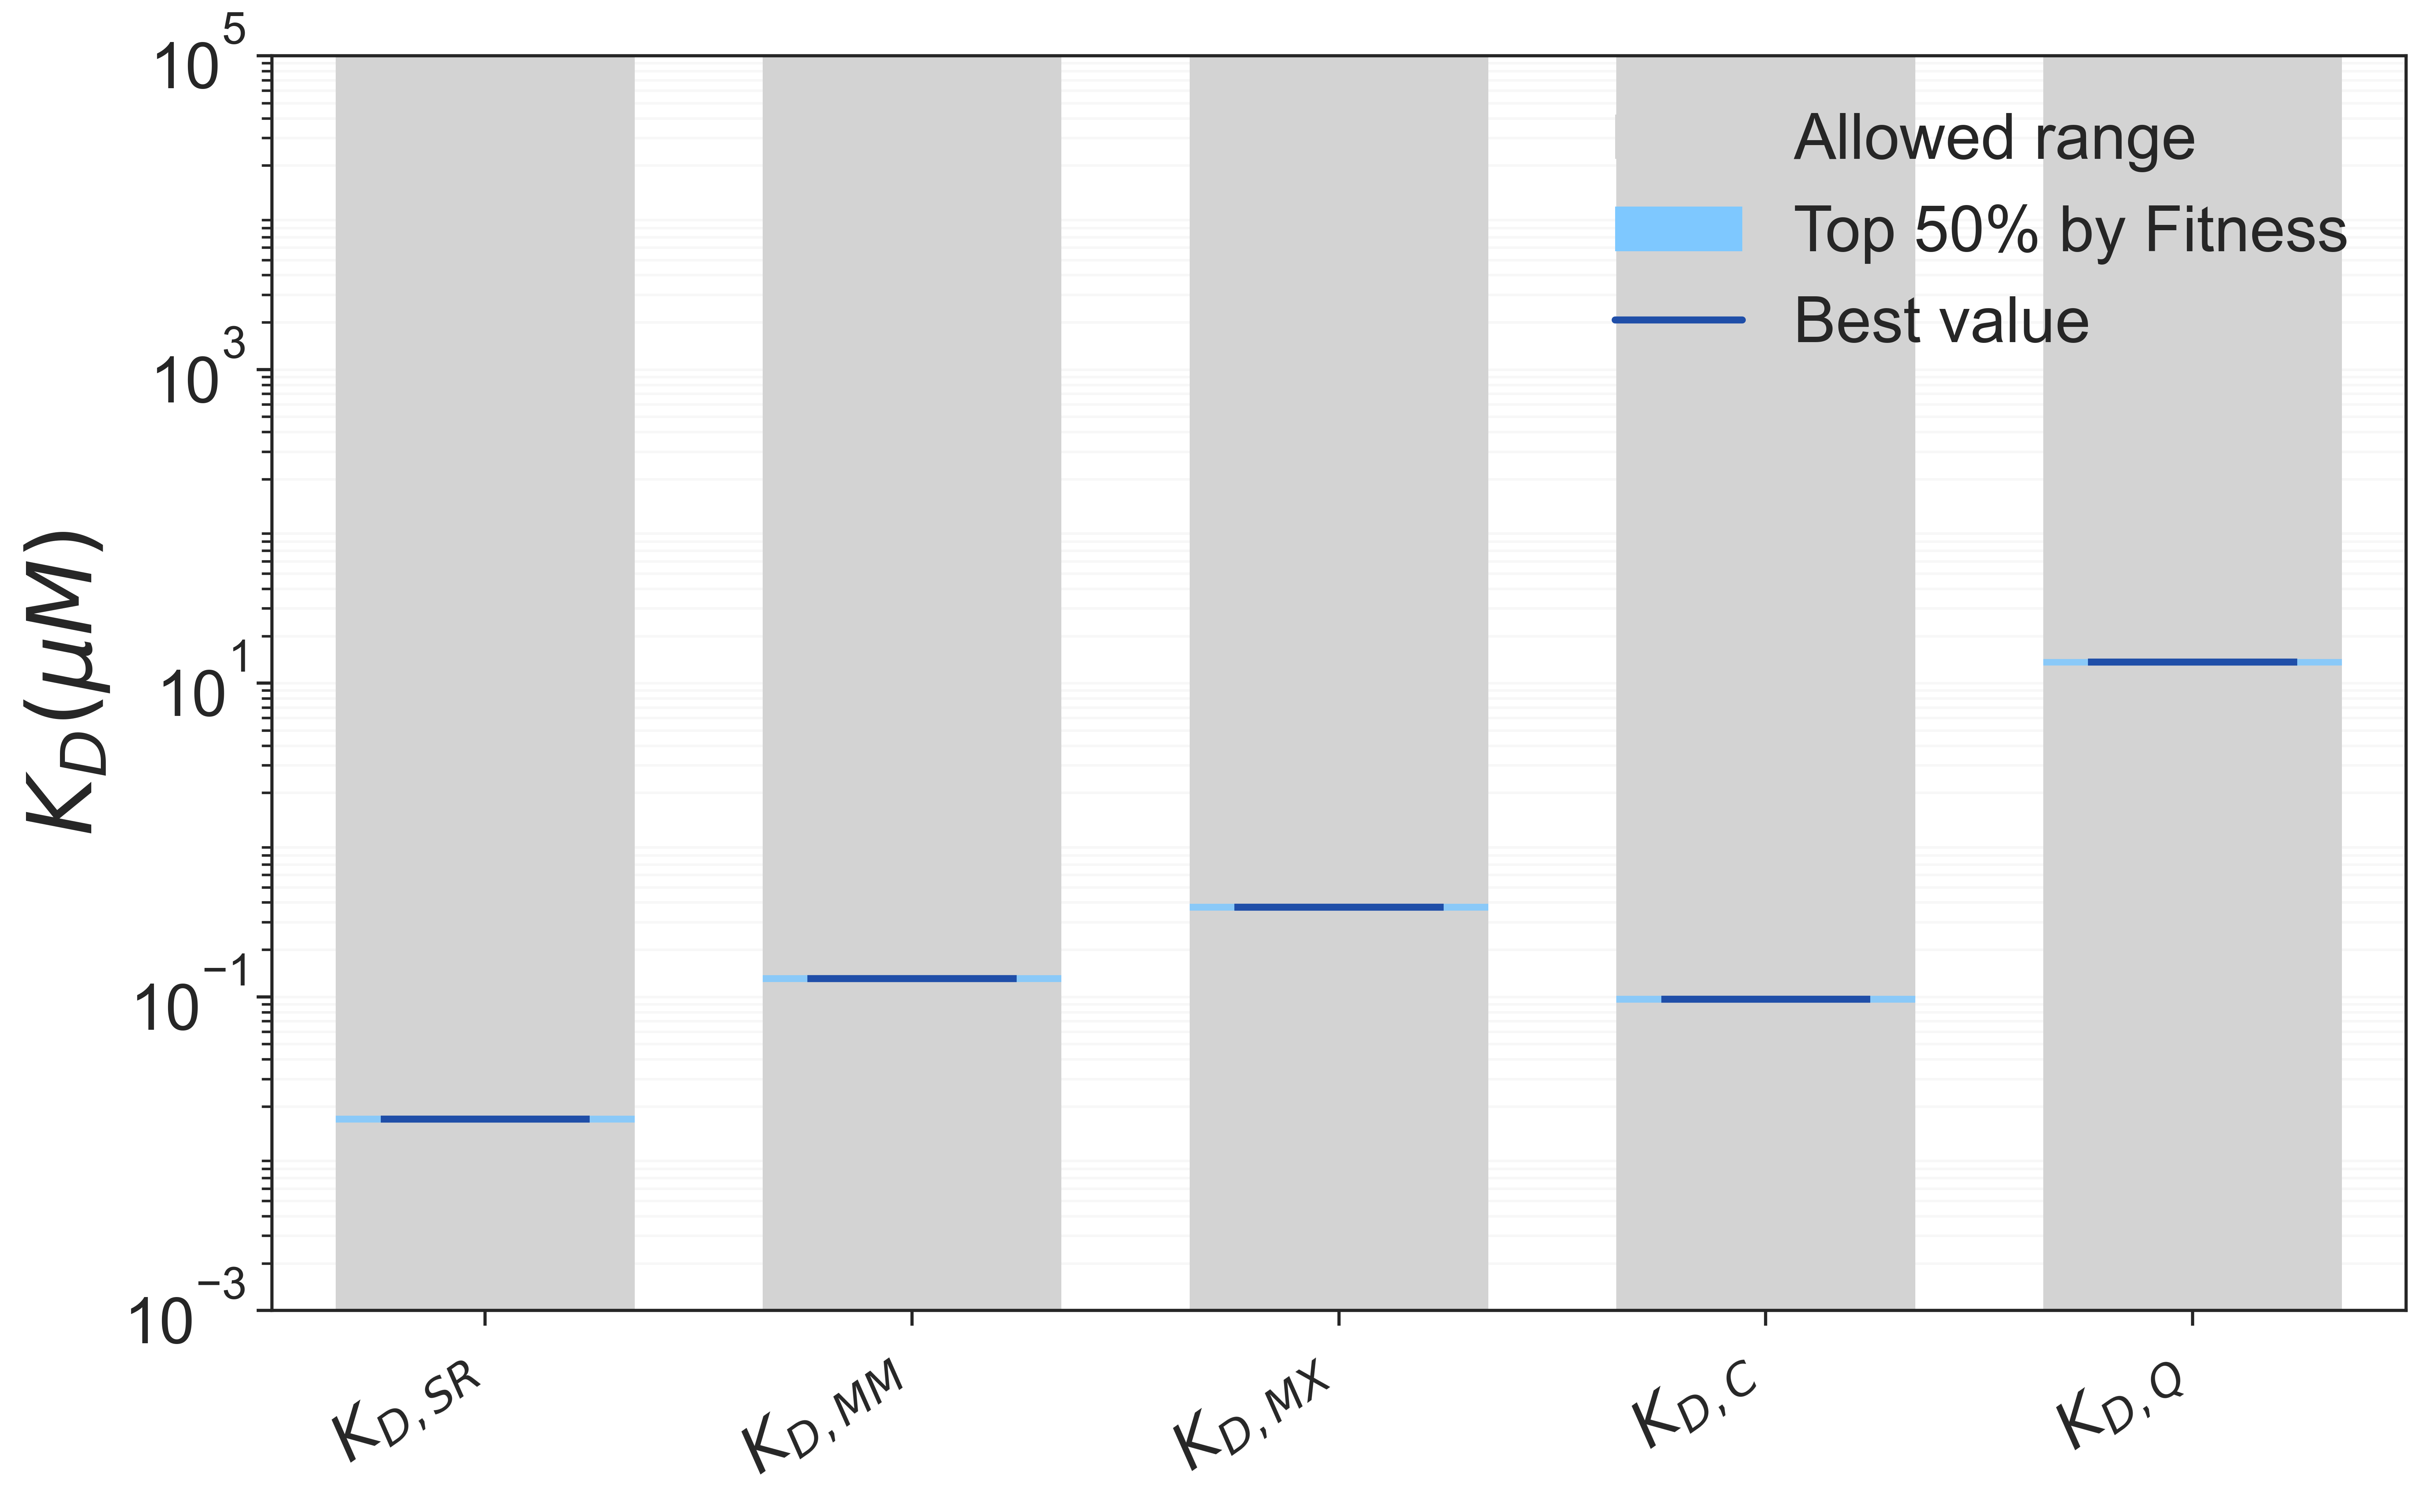

In [61]:
# show the distirbution of KD values.
# add an explicit penalty to diffusion, by 1.1 or 1.05 slower. 
#all top solutions
inputFile = f"{dir}/Top11_solutions_Dterm_parameters_{unique_id}.csv"
model.plot_parameter_KD_summary(percent=50, fontsize = 20, save_path=f"{imageDir}/sensitivity_KD_Top11_{unique_id}.png",inputFile=inputFile)
#solutions with correct diffusion behavior
inputFile=f"{dir}/parameter_solutions_Dslows_{unique_id}.csv"
model.plot_parameter_KD_summary(percent=50, fontsize = 20, save_path=f"{imageDir}/sensitivity_KD_Top11_Dslows_{unique_id}.png",inputFile=inputFile)


# distribution of sampled KD values from centroids

Total solutions loaded: 30
Using top 50% by Fitness -> 15 solutions.
p:  kDsr
best_row     kDsr      kDmm      kDmx       kDc       kDq
0  3.604  0.068004  0.087098  0.026503  7.737729
p:  kDmm
best_row     kDsr      kDmm      kDmx       kDc       kDq
0  3.604  0.068004  0.087098  0.026503  7.737729
p:  kDmx
best_row     kDsr      kDmm      kDmx       kDc       kDq
0  3.604  0.068004  0.087098  0.026503  7.737729
p:  kDc
best_row     kDsr      kDmm      kDmx       kDc       kDq
0  3.604  0.068004  0.087098  0.026503  7.737729
p:  kDq
best_row     kDsr      kDmm      kDmx       kDc       kDq
0  3.604  0.068004  0.087098  0.026503  7.737729


/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), ti

Saved summary to: /Users/margaret/Dropbox/r2025/Munc13/IMAGES/Data_for_plots/sensitivity_KD_Centroid.png
Total solutions loaded: 15
Using top 50% by Fitness -> 7 solutions.
p:  kDsr
best_row        kDsr      kDmm       kDmx       kDc       kDq
0  3.119037  0.068071  11.929411  0.018447  9.190576
p:  kDmm
best_row        kDsr      kDmm       kDmx       kDc       kDq
0  3.119037  0.068071  11.929411  0.018447  9.190576
p:  kDmx
best_row        kDsr      kDmm       kDmx       kDc       kDq
0  3.119037  0.068071  11.929411  0.018447  9.190576
p:  kDc
best_row        kDsr      kDmm       kDmx       kDc       kDq
0  3.119037  0.068071  11.929411  0.018447  9.190576
p:  kDq
best_row        kDsr      kDmm       kDmx       kDc       kDq
0  3.119037  0.068071  11.929411  0.018447  9.190576


/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), tiny)
/Users/margaret/github/munc13-cluster/ode/source/munc13.py:2593: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  best_val = max(float(best_row[p]), ti

Saved summary to: /Users/margaret/Dropbox/r2025/Munc13/IMAGES/Data_for_plots/sensitivity_KD_Centroid_Dslows.png


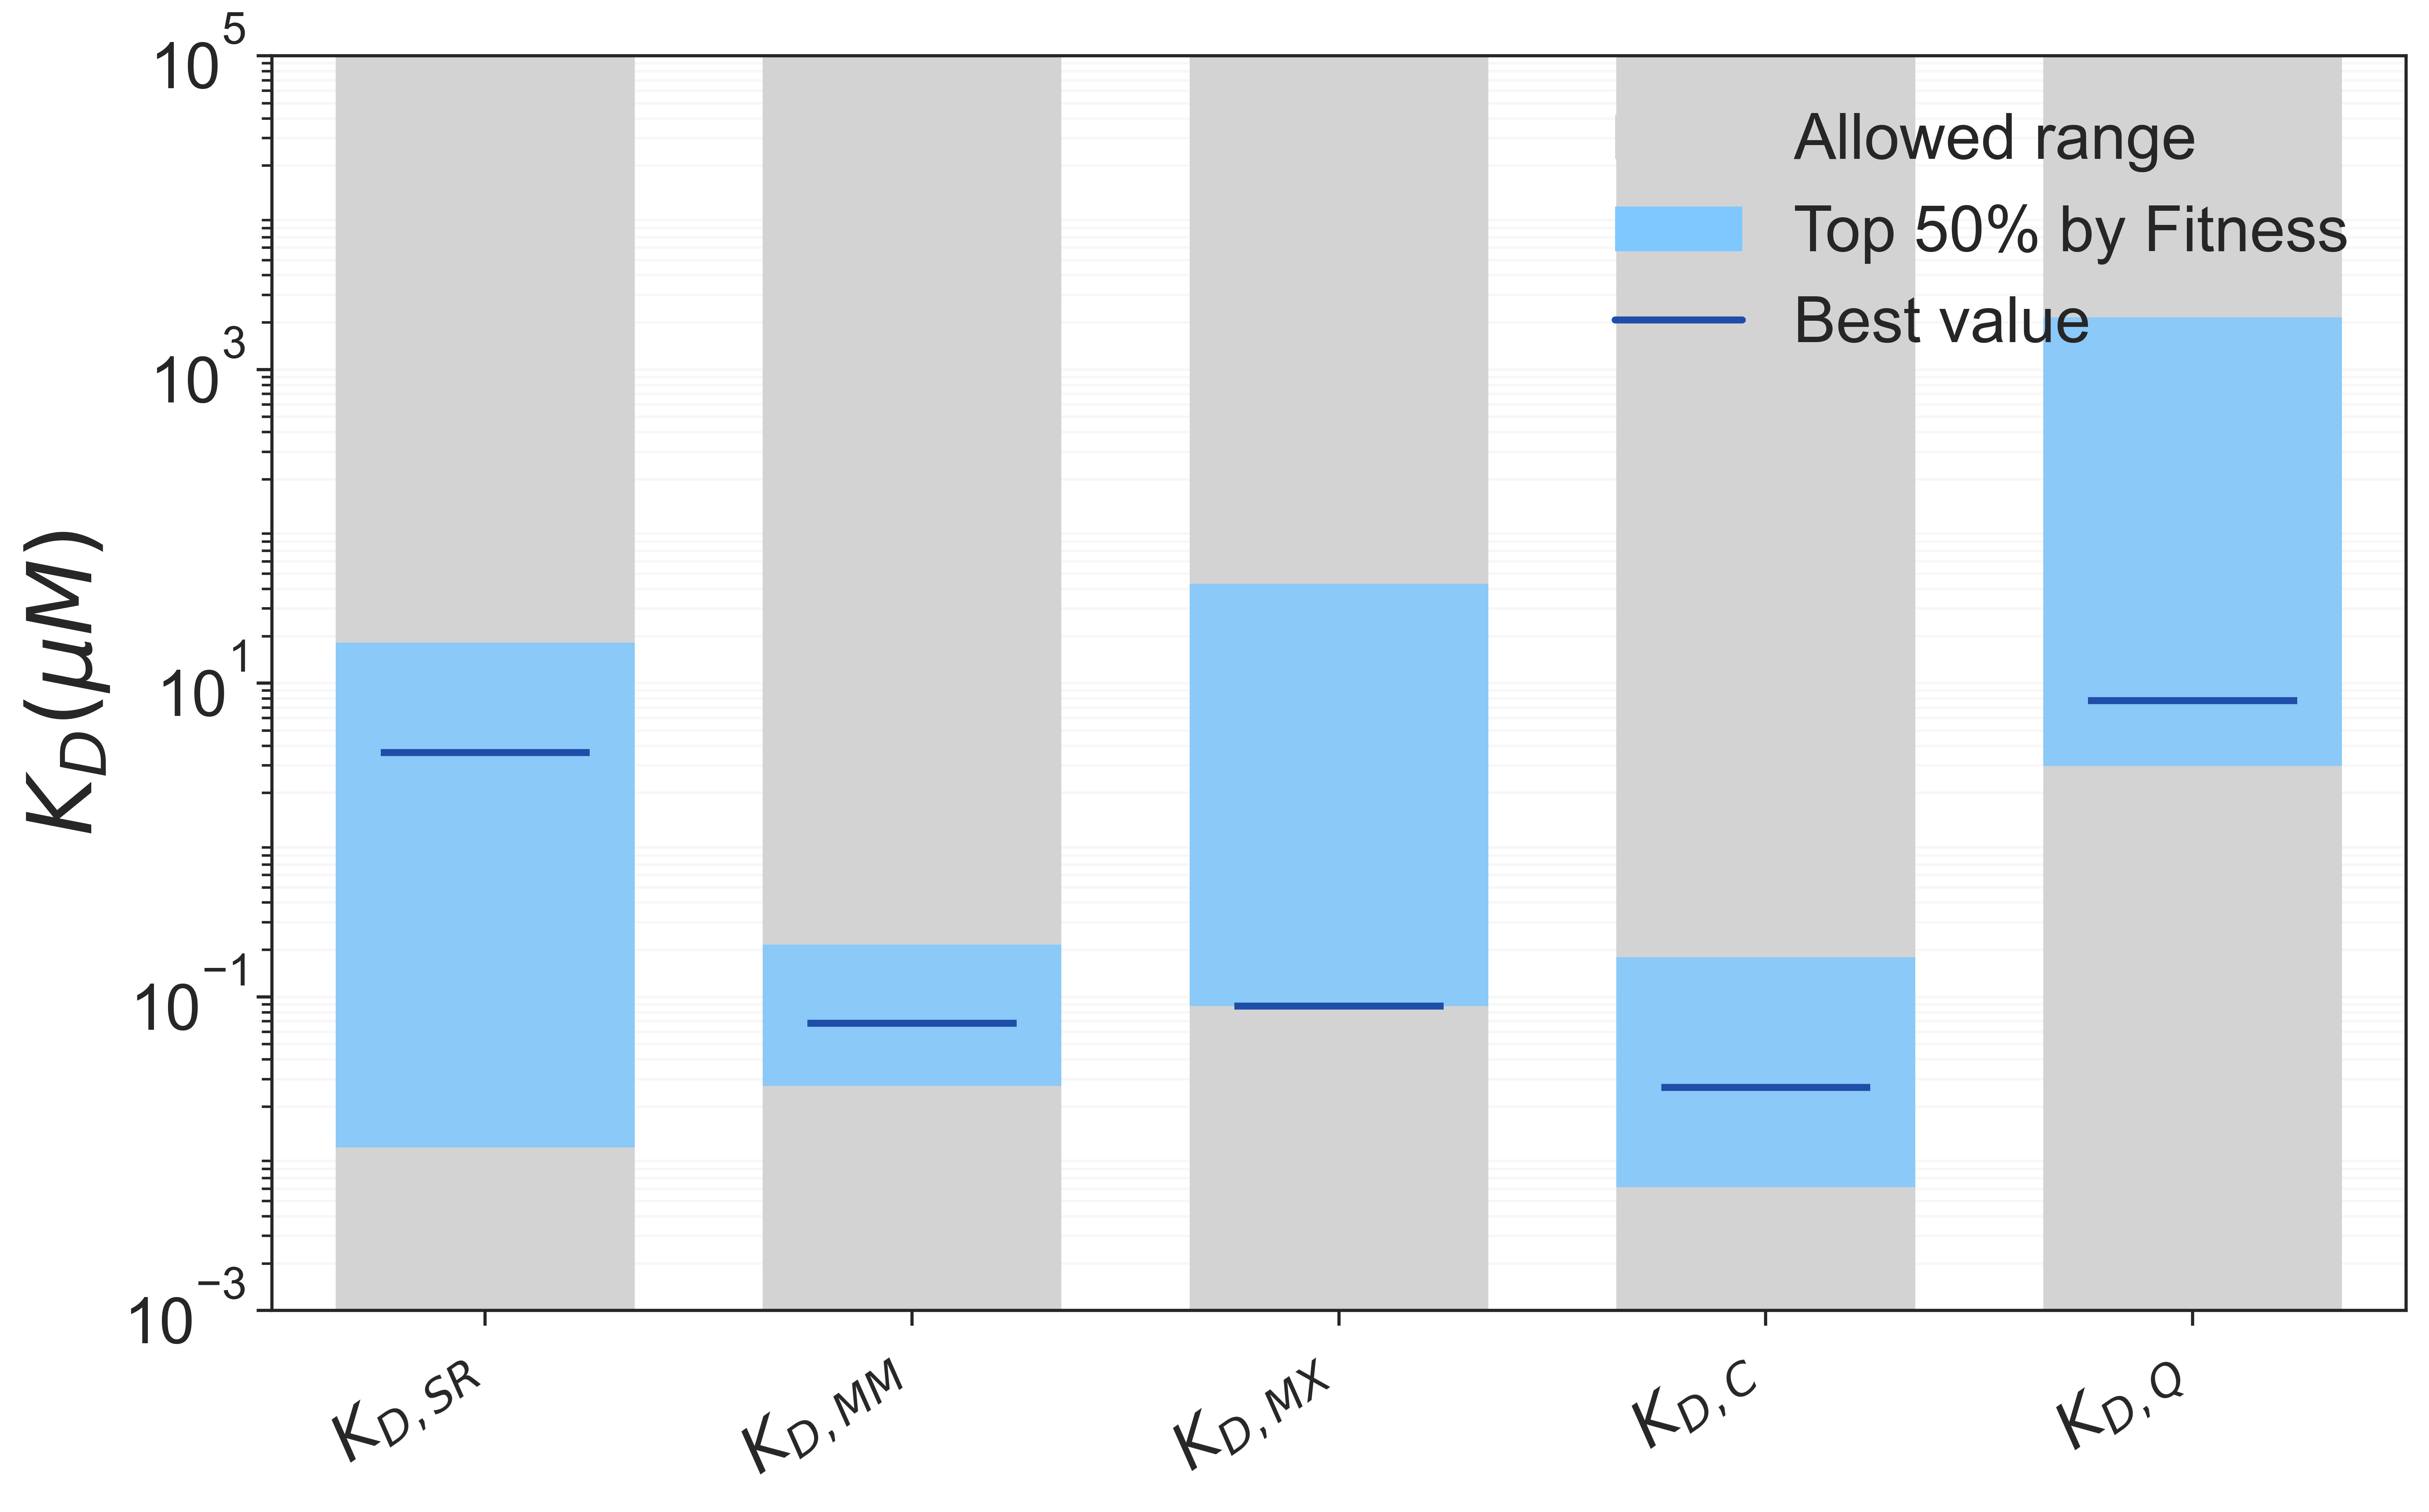

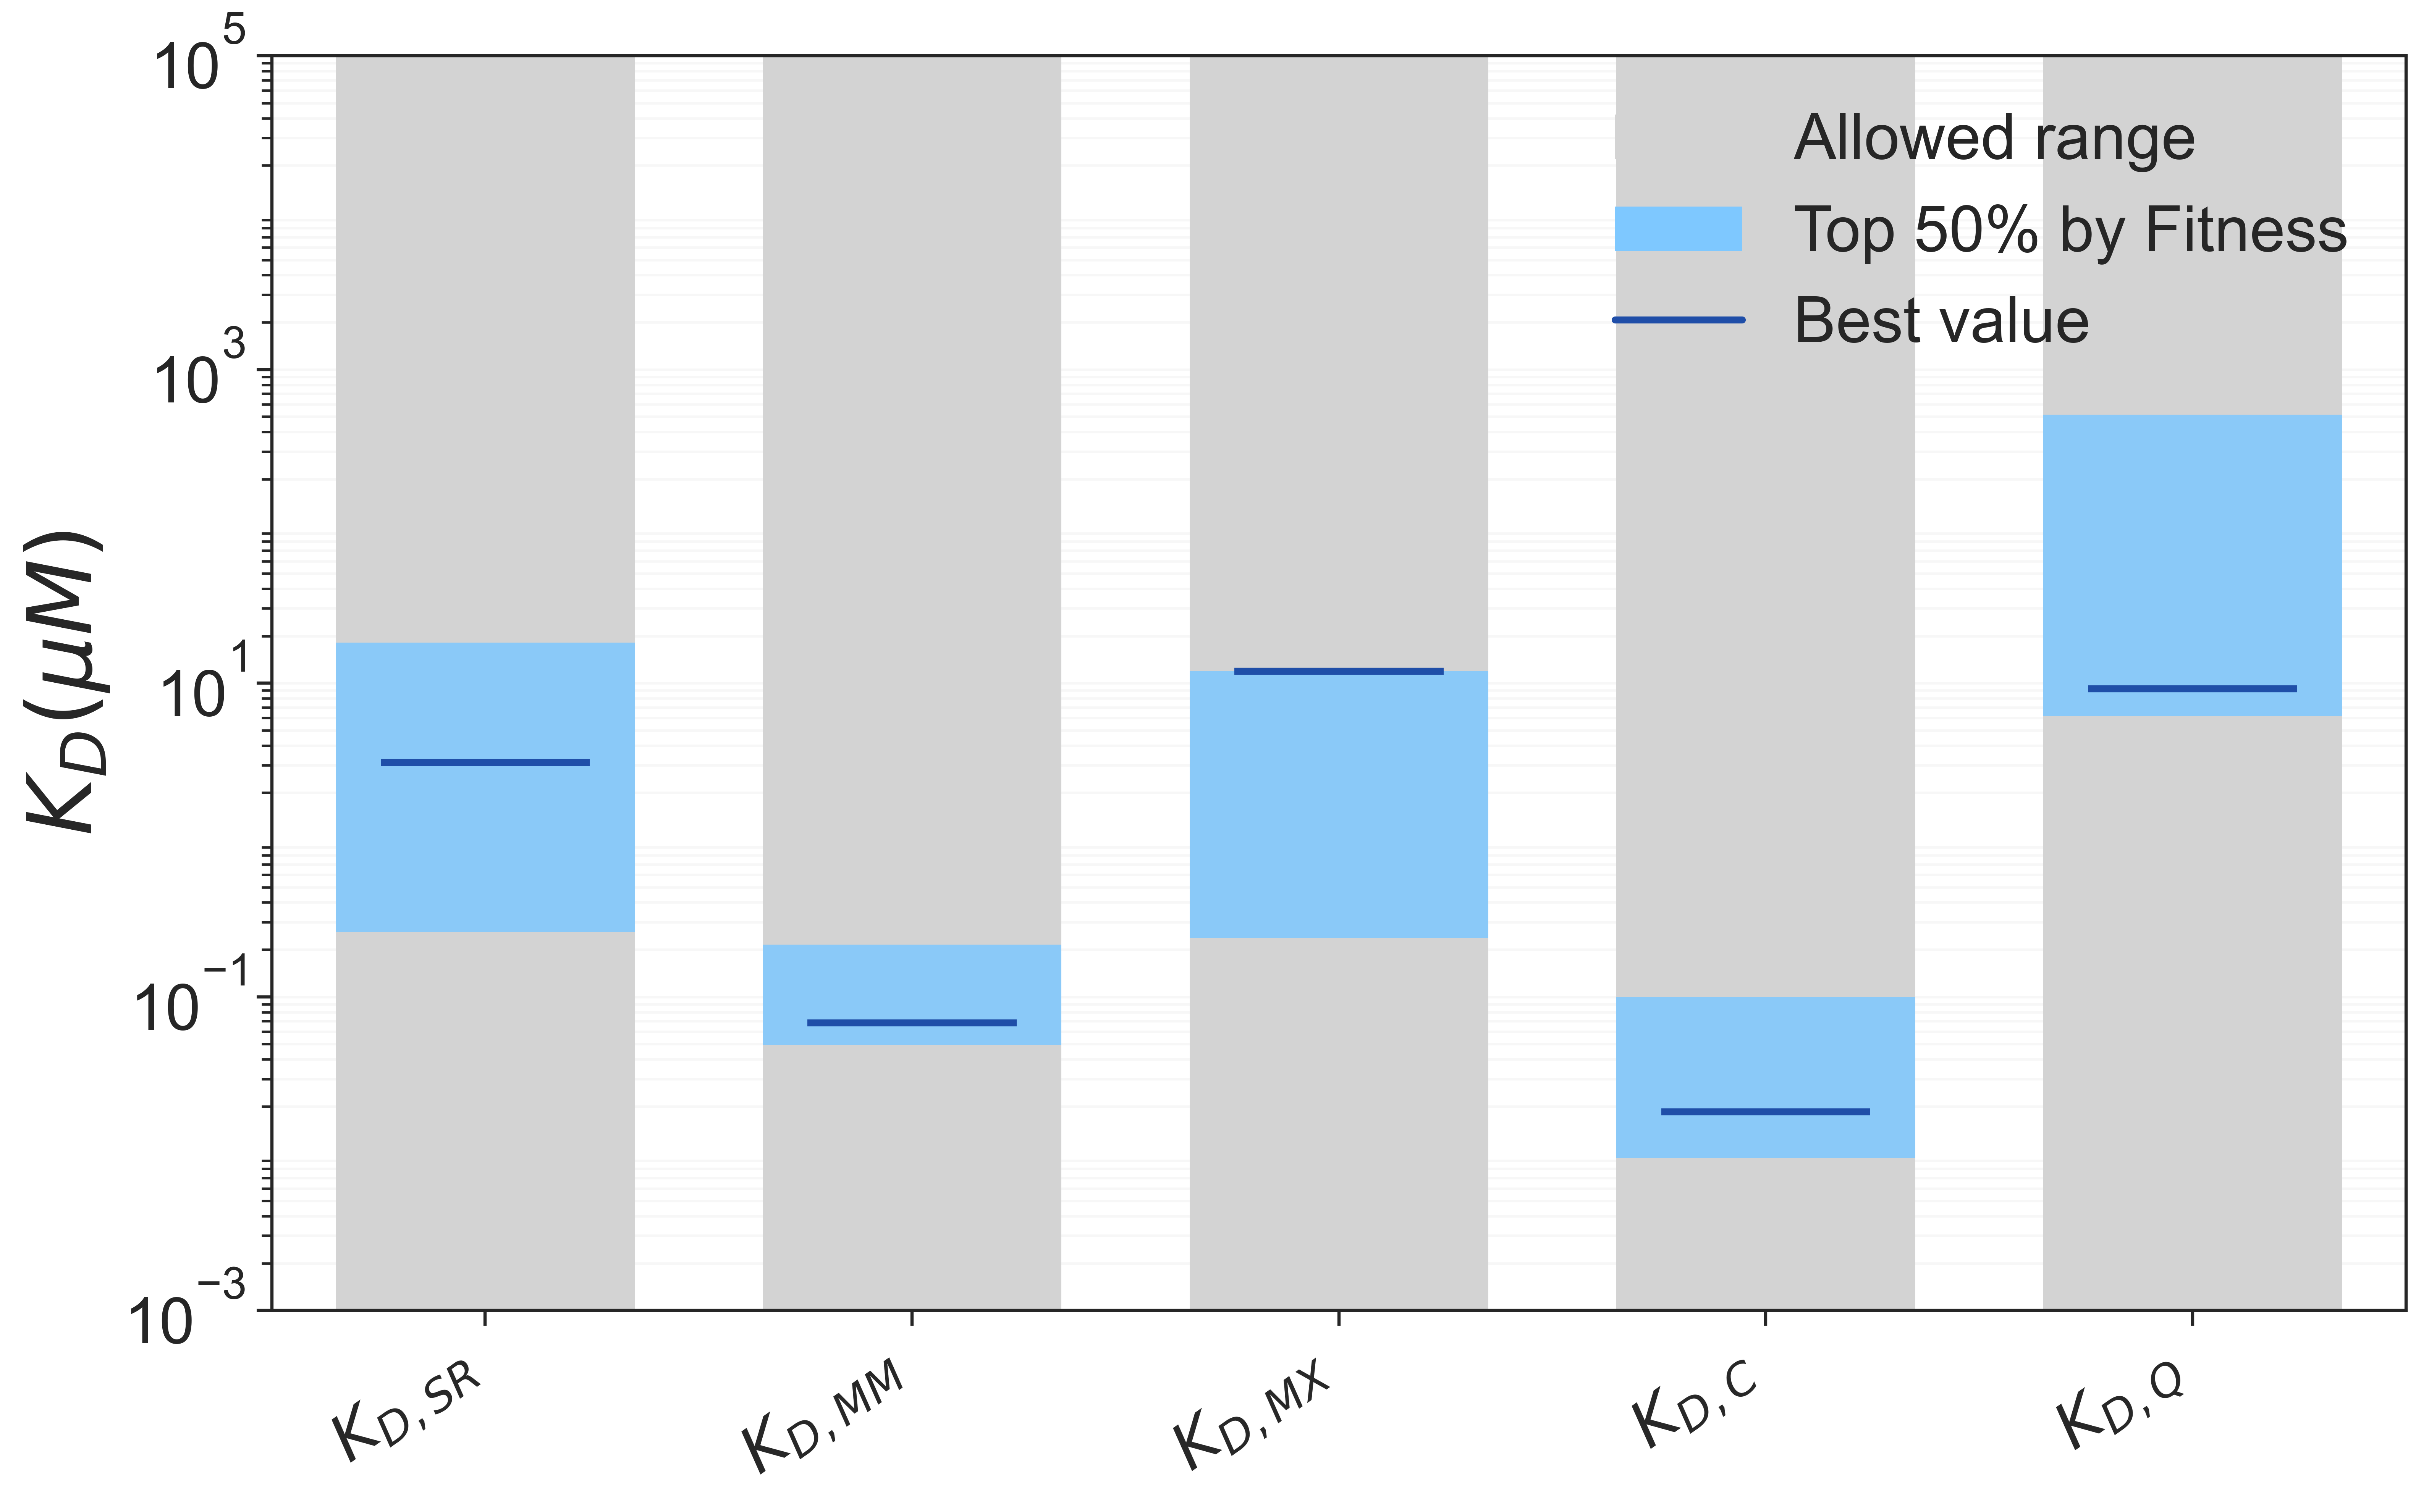

In [62]:
# show the distirbution of KD values.
# add an explicit penalty to diffusion, by 1.1 or 1.05 slower. 
#all top solutions

model.plot_parameter_KD_summary(percent=50, fontsize = 20, save_path=f"{dir}/sensitivity_KD_Centroid.png",inputFile=allCentroidParmFile)
#solutions with correct diffusion behavior
model.plot_parameter_KD_summary(percent=50, fontsize = 20, save_path=f"{dir}/sensitivity_KD_Centroid_Dslows.png",inputFile=parmFileSave)


# what happens if total munc13 is lowered to cluster density and diffusion

In [63]:
#first make sure you go back to the original candidate
candidate=selected_solutions[param_cols].iloc[whichRow].values

print(candidate)
print(selected_solutions.iloc[whichRow])
print('exp_metrics: ', exp_metrics.iloc[whichRow])
endo_candidate=list(candidate)
#change the munc13 concentration
endo_candidate[15]=endo_candidate[15]*0.3
#print(endo_candidate[15])
solOrig, solOrigPost=model.simulate(candidate)
sol, solPost=model.simulate(endo_candidate)

model.test_mass_conservation(sol)

[3.7968e+00 2.7101e+01 9.1023e-01 4.1931e-02 8.7232e-01 1.8677e+01
 7.7286e+00 2.4674e-02 7.2982e-01 6.2915e-01 3.4027e+00 6.1623e-03
 8.9751e-02 9.6770e-01 2.6779e+00 4.4323e-03 4.5357e+02 2.3500e-02
 5.0953e-50]
Rank        0.000000e+00
Fitness    -2.729700e+00
kfsr        3.796800e+00
krsr        2.710100e+01
kfmm        9.102300e-01
krmm        4.193100e-02
kfmx        8.723200e-01
krmx        1.867700e+01
kfc         7.728600e+00
krc         2.467400e-02
kfq         7.298200e-01
krq         6.291500e-01
eLoop       3.402700e+00
eDF         6.162300e-03
kfdd        8.975100e-02
Sd          9.677000e-01
stimUpSR    2.677900e+00
S0          4.432300e-03
R0          4.535700e+02
X0          2.350000e-02
Q0          5.095300e-50
Name: 0, dtype: float64
exp_metrics:  tau56        1.135094e+01
tau56Post    1.135081e+01
densPre      2.287987e-02
densPost     2.323395e-02
stimFact     3.248136e+00
percClust    1.887081e-01
percCPost    5.899645e-02
percDimer    4.994131e-01
percDPost    7.

In [64]:
specieNames=['S','R','M','D','X','S2','MX','SX','M2X','DX','Q','SQ','S2Q2','M3X','M4X','M5X','M6X','D2X','D3X','DMX','DM2X','D2MX','D2M2X']
len(specieNames)
endoDF=pd.DataFrame([sol[:,-1], solOrig[:,-1]],columns=specieNames)
print(endoDF['D'])

0    0.000010
1    0.000091
Name: D, dtype: float64


In [65]:
percClusterTotalEndo, percClustMemEndo, percMemEndo, pMonoEndo, pDimerEndo, pMXEndo, pDXEndo=model.calc_percentages_cluster(sol)
percClusterTotalOrig, percClustMemOrig, percMemOrig, pMonoOrig, pDimerOrig, pMXOrig, pDXOrig=model.calc_percentages_cluster(solOrig)
memCopyMuncEndo =   model.calculate_munc13_on_membrane(sol[:,-1]*model.cellVolume*602)      
memCopyMuncOrig =   model.calculate_munc13_on_membrane(solOrig[:,-1]*model.cellVolume*602)
print('memcopies, endo, orig', memCopyMuncEndo, memCopyMuncOrig)
print('pmono', pMonoEndo, pMonoOrig)
print('pdimer, ', pDimerEndo, pDimerOrig)

memcopies, endo, orig 212.16535040180793 913.700417786442
pmono 0.44546298895181197 0.3078276239815862
pdimer,  0.23851401927410698 0.4994131276091714


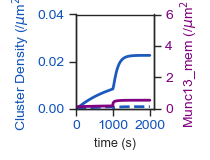

sizes pre stim, and sum:  [np.float64(0.44546298895181197), np.float64(0.23851401927410698), np.float64(0.2942079229925656)]
sizes POST stim, and sum:  [np.float64(0.32705821174314037), np.float64(0.40977614817846425), np.float64(0.25589981901699443)]


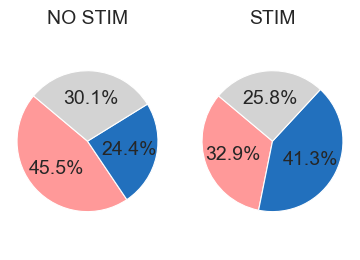

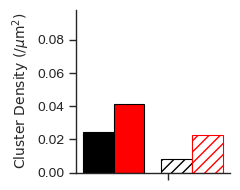

In [66]:
model.plot_time_resolved_density(sol, solPost,f"ENDO_{unique_id}_{whichRow}")
#create pie charts.
model.pie_charts(sol, solPost, [4,3], f"ENDO_{unique_id}_{whichRow}")
#plot cluster density as a bar plot
model.plot_density_vs_exp(sol, solPost, f"ENDO_{unique_id}_{whichRow}", whichExp='WT')

In [67]:
#plot diffusion, compare with WT overexpressed
[metricsWTOrig,metricsC2AOrig, metricsDOrig]=model.compute_all_metrics(candidate)
[metricsWTEndo,metricsC2AEndo, metricsDEndo]=model.compute_all_metrics(endo_candidate)

exp_endo_metrics = pd.DataFrame([metricsWT], columns=colWT)
C2A_endo_metrics = pd.DataFrame([metricsC2A], columns=colC2A)
D_endo_metrics = pd.DataFrame([metricsD], columns = colD)


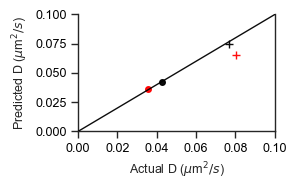

In [68]:
#plot diffusion, compare with WT overexpressed
[metricsWT,metricsC2A, metricsD]=model.compute_all_metrics(endo_candidate)
exp_endo_metrics = pd.DataFrame([metricsWT], columns=colWT)
C2A_endo_metrics = pd.DataFrame([metricsC2A], columns=colC2A)
D_endo_metrics = pd.DataFrame([metricsD], columns = colD)

fig, ax = plt.subplots(figsize=(3, 2))
D=D_endo_metrics['D'].iloc[0]
Dpost=D_endo_metrics['Dpost'].iloc[0]
DC2A=D_endo_metrics['C2AD'].iloc[0]
DC2Apost=D_endo_metrics['C2ADpost'].iloc[0]
ax.plot(model.D_exp_pre,D, markersize=4, marker='o', color='black', alpha=0.95, zorder=3)
ax.plot(model.D_exp_post,Dpost, markersize=4, marker='o', color='red', alpha=0.95, zorder=3)
ax.plot(model.D_exp_DC2A_pre,DC2A, markersize=6, marker='+', color='black', alpha=0.95, zorder=3)
ax.plot(model.D_exp_DC2A_post,DC2Apost, markersize=6, marker='+', color='red', alpha=0.95, zorder=3)
ax.plot(np.arange(0, 10)*0.1,np.arange(0, 10)*0.1, linewidth=1, ls='-', color='black', alpha=0.95, zorder=3)

ax.set_xlim(left=0, right=0.1)
ax.set_ylim(bottom=0, top=0.1)
ax.set_xlabel("Actual D ($\\mu$m$^2/s$)", fontsize=9)
ax.set_ylabel("Predicted D ($\\mu$m$^2/s$)", fontsize=9)
ax.tick_params(axis='both',labelcolor='black', labelsize=9)
#ax.set_xticks([0, 1000,2000])
# Get rid of bound box on the top.
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(f"/Users/margaret/Dropbox/r2025/Munc13/IMAGES/Diffusion_ENDO_{unique_id}_{whichRow}.png",dpi=300)
plt.show()

In [69]:
print(D_endo_metrics['D'].iloc[0])


0.04188290876478741


In [70]:
print(D_metrics['D'].iloc[whichRow])

0.037283929722751734


D, D endo 0.037283929722751734 0.04188290876478741


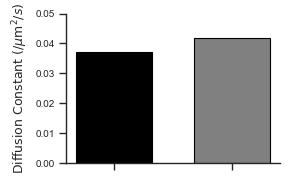

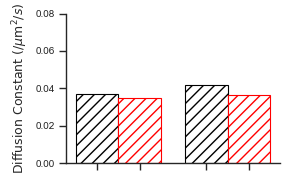

In [71]:
#make a bar plot of diffusion following lower
fig, ax = plt.subplots(figsize=(3,2))
print('D, D endo',D_metrics['D'].iloc[whichRow], D_endo_metrics['D'].iloc[0])
bar_width=0.18

fontsize=9
gap=0.1
centers=[0.9, 0.9+bar_width+gap]
ax.bar(0.9,  D_metrics['D'].iloc[whichRow],  width=bar_width,  capsize=4,
            color='black',   edgecolor='black', label='Exp (NO STIM)')
ax.bar(0.9+bar_width+gap, D_endo_metrics['D'].iloc[0], width=bar_width, capsize=4,
            color='gray', edgecolor='black', label='Exp (STIM)')
# Axes/labels
ax.set_ylabel(r"$\mathrm{Diffusion\ Constant}\ (/\mu\mathrm{m}^2/s)$", fontsize=fontsize)
ax.set_xticks(centers)
ax.set_xticklabels([], fontsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize * 0.8)
ax.set_ylim(bottom=0, top=0.05)

# Adjust layout to fit
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Cleanup
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
dpi=300
fig.savefig(f"{dir}/diffusion_WT_vs_endogenousGray_{unique_id}_{whichRow}.png", dpi=dpi) 

model.plot_diffusion_as_barplot(D_metrics['D'].iloc[whichRow], D_metrics['Dpost'].iloc[whichRow],D_endo_metrics['D'].iloc[0], D_endo_metrics['Dpost'].iloc[0], fileStr=f"_{unique_id}_{whichRow}_ENDO_both")

In [72]:
print(exp_endo_metrics)
print(exp_metrics)

       tau56  tau56Post   densPre  densPost  stimFact  percClust  percCPost  \
0  11.267558  11.350781  0.008283  0.022617   3.13926   0.294208     0.2559   

   percDimer  percDPost    SSval  SSvalPost  
0   0.238514   0.409776  0.00145   0.000018  
       tau56  tau56Post   densPre  densPost  stimFact  percClust  percCPost  \
0  11.350935  11.350810  0.022880  0.023234  3.248136   0.188708   0.058996   
1  11.075859  11.080314  0.025790  0.026726  2.595117   0.144183   0.057576   
2  10.967187  10.968501  0.025425  0.025532  2.719191   0.136002   0.050226   
3  11.944974  11.950579  0.023131  0.023343  3.044164   0.124338   0.041220   
4   7.006471   7.014586  0.023470  0.024746  2.631956   0.111423   0.044635   

   percDimer  percDPost         SSval     SSvalPost  
0   0.499413   0.733197 -2.263517e-07 -2.726658e-10  
1   0.426699   0.622910  3.108511e-04  3.688470e-07  
2   0.415807   0.621796  2.682545e-04  4.174546e-09  
3   0.467345   0.678409  7.340695e-05  7.808782e-07  
4   

# make plots for lipid impairment

In [73]:
#now lower the kfsr, and also set the stimUp to 1. 
pip_candidate=list(candidate)
pip_candidate[0]=pip_candidate[0]*0.5 #kfsr
pip_candidate[14]=1.0 #stimUpSR
#R0 is [16]
#pip_candidate[16]=pip_candidate[16]*0.2

sol, solPost=model.simulate(pip_candidate)

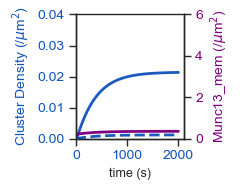

sizes pre stim, and sum:  [np.float64(0.3433533261017695), np.float64(0.28981599270841735), np.float64(0.35139816653414935)]
sizes POST stim, and sum:  [np.float64(0.3340432107965924), np.float64(0.28337450796403163), np.float64(0.3664883806396865)]


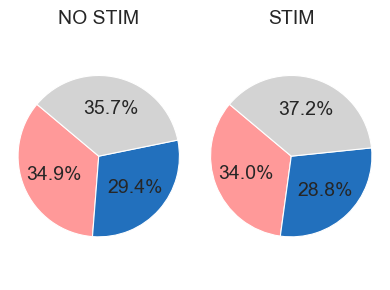

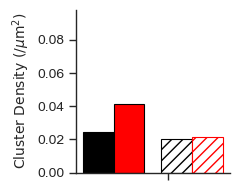

In [74]:
model.plot_time_resolved_density(sol, solPost,f"dPIP_{unique_id}_{whichRow}")
#create pie charts.
model.pie_charts(sol, solPost, [4,3], f"dPIP_{unique_id}_{whichRow}")
#plot cluster density as a bar plot
model.plot_density_vs_exp(sol, solPost, f"dPIP_{unique_id}_{whichRow}", whichExp='WT')

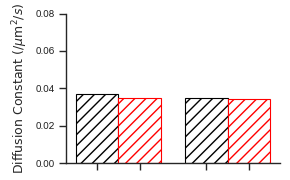

In [75]:
#plot diffusion, compare with WT overexpressed
[metricsWT,metricsC2A, metricsD]=model.compute_all_metrics(pip_candidate)
exp_pip_metrics = pd.DataFrame([metricsWT], columns=colWT)
C2A_pip_metrics = pd.DataFrame([metricsC2A], columns=colC2A)
D_pip_metrics = pd.DataFrame([metricsD], columns = colD)

model.plot_diffusion_as_barplot(D_metrics['D'].iloc[whichRow], D_metrics['Dpost'].iloc[whichRow],D_pip_metrics['D'].iloc[0], D_pip_metrics['Dpost'].iloc[0], fileStr=f"_{unique_id}_{whichRow}_dPIP")